In [1]:
# Tutorial environment
using Pkg, NTRsurv
pkg_dir = pkgdir(NTRsurv)
Pkg.activate(joinpath(pkg_dir, "examples"))
Pkg.instantiate()

  Activating project at `~/NTRsurv.jl/examples`


In [2]:
## Load packages and extra code needed for tutorial
using Random, Distributions, Survival, StatsModels, DataFrames, HCubature, NTRsurv, Plots, Measures, LaTeXStrings
# Code for frequentist confidence bands
frequentist_confidence_bands_path = joinpath( dirname(dirname(pathof(NTRsurv))), "examples", "frequentist_confidence_bands.jl")
include(frequentist_confidence_bands_path)

bootstrap_rmst (generic function with 2 methods)

In [3]:
# Set seed for reproducibility
Random.seed!(1234)

TaskLocalRNG()

# Weibull Simulation Study for Bayesian Nonparametric Survival Analysis with Neutral-to-the-Right Priors workflow of NTRsurv.jl

This notebook provides an in-depth presentation of a 
Neutral-to-the-Right (NTR) survival modeling workflow. 
We review key theoretical results from the literature, including 
posterior consistency at the optimal rate relative to the 
Kaplan–Meier estimator and a Bernstein–von Mises result 
for the Cox proportional hazards model, which justify the modeling approach. 
We also describe efficient posterior simulation schemes and 
demonstrate a full implementation using synthetic Weibull data 
with the Julia package 
[NTRsurv.jl](https://github.com/alan7riva/NTRsurv.jl).

A comprehensive theoretical introduction to NTR priors appears in 
Chapter 13 of 
[*Fundamentals of Nonparametric Bayesian Inference* 
(Ghosal & van der Vaart, 2017)](https://www.cambridge.org/core/books/fundamentals-of-nonparametric-bayesian-inference/C96325101025D308C9F31F4470DEA2E8). 
Further developments for dependent survival data, together with 
computational advances underlying the present implementation, 
are presented in 
[*Bayesian Nonparametric Methods for Heterogeneous Data* 
(Riva-Palacio, 2019)](https://kar.kent.ac.uk/74521/).

For a more hands-on introduction focused on applied data analysis, 
see the companion tutorials that emphasize practical modeling 
without extensive theoretical development.

## NTR distributions for Kaplan-Meier alternative

We say that a random probability distribution supported on $\mathbb{R}^+$, with cumulative distribution function $F$, is neutral to the right if for positive real numbers $0\leq t_1<\ldots <t_n$ the random vector

$$
(V_1,\ldots,V_n)=\left( F(t_1),\frac{F(t_2)-F(t_1)}{1-F(t_1)}, \ldots , \frac{F(t_n)-F(t_{n-1})}{1-F(t_{n-1})}\right)
$$

has mutually independent entries.

Such distributions can be characterized by having survival function 

$$
S(t)=1-F(t)=\exp\left(-Y(t) \right)
$$

where $Y(t)$ is an almost surely non-decreasing function with independent increments, known in the stochastic processes literature as a subordinator. We say that a random variable with survival function $S$ as above has a $\text{NTR}(Y)$ distribution. The so called subordinator $Y$ is in turn characterized by a Poisson process $N$ with intensity $\nu(\mathrm{d}w,\mathrm{d}u)$ in $\mathbb{R}^+\times\mathbb{R}^⁺$, the "w" axis corresponding to weights in the jumps of $Y$ while the "u" axis corresponds to locations of those jumps, such that we can express

$$
Y(t)=\int_0^\infty \int_0^t N(w,u)\mathrm{d}w\mathrm{d}u,
$$

where the so called Lévy intensity satisfies the integrability condition $\int_{ [0,t] \times \mathbb{R}_+} (1 - e^{-w} )\nu(\mathrm{d}w,\mathrm{d}u) < \infty $ for any $t>0$. Such subordinators have an almost sure representation 

$$
Y(t) \stackrel{\text{a.s.}}{=} \sum_{i=1}^\infty W_i \pmb{1}\left\{ U_i \leq t \right\}
$$

for some r.v.'s $U_i,W_i\stackrel{\text{a.s.}}{>}0$ determined by the intensity $\nu$ such that $Y(t)$ is a.s. finite for any $t>0$. 

Particular choices of subordinators can have know distribution of their increments, usually providing easier agorithms for stochastic simulation. One such example is the following Gamma process.

**NTR with Gamma processes workflow for survival analysis**

If the intensity $\nu$ has the form

$$
\nu(\mathrm{d}w,\mathrm{d}u)  = \beta \frac{e^{-\alpha w}}{w} \mathrm{d}w \mathrm{d} \kappa(u)
$$

with $\alpha,\beta>0$ we say that the associated subordinator is a Gamma process as it can be checked that

$$
Y(t)\sim \text{Gamma}(\text{shape}=\beta\kappa(t),\text{ rate}=\alpha)
$$

The Laplace exponent of a Gamma process is given by
\begin{align*}
\psi_t(\lambda) = -\log\left( \mathbb{E}\left[ e^{-\lambda Y(t)} \right] \right) = \beta \log\left( 1 +\frac{\lambda}{\alpha} \right) \kappa(t).
\end{align*}

We choose $$\beta = \frac{1}{\log\left( 1+\frac{1}{\alpha} \right)}$$ with which

$$
\mathbb{E}\left[ S(t) \right]=e^{-\psi_t(1)} = e^{ -\kappa(t) },
$$

so $\kappa$ serves as a cumulative hazard baseline for centering the model a priori.

On the other hand
$$
\mathbb{E}\left[ (S(t))^2 \right]=e^{-\psi_t(2)} = exp\left( -\frac{\log\left(1+\frac{2}{\alpha} \right)}{\log\left(1+\frac{1}{\alpha} \right)} \kappa(t)   \right)
$$
and

$$
\text{Var}\left( S(t) \right) = exp\left( -\frac{\log\left(1+\frac{2}{\alpha} \right)}{\log\left(1+\frac{1}{\alpha} \right)} \kappa(t)   \right) - e^{-2\kappa(t)}.
$$

We observe that

$$
\frac{\log\left(1+\frac{\lambda}{\alpha} \right)}{\log\left(1+\frac{1}{\alpha} \right)}
=\frac{\log\left(\alpha + \lambda  \right) - \log(\alpha)}{ \log\left(\alpha+ 1 \right) - \log(\alpha)}
= \frac{ \frac{ \log\left(\alpha + \lambda  \right) }{\log(\alpha)} - 1}{ \frac{ \log\left(\alpha+ 1 \right) }{\log(\alpha)} - 1 }
$$

so

$$
\lim\limits_{\alpha \to 0} \frac{\log\left(1+\frac{\lambda}{\alpha} \right)}{\log\left(1+\frac{1}{\alpha} \right)}=1
$$

and by de L'Hopital's rule

\begin{align*}
\lim\limits_{\alpha \to \infty} \frac{\log\left(1+\frac{\lambda}{\alpha} \right)}{\log\left(1+\frac{1}{\alpha} \right)} &= \lim\limits_{\alpha \to \infty} \frac{ \log(\alpha+\lambda)-\log(\alpha) }{ \log(\alpha+1)-\log(\alpha) }=
\lim\limits_{\alpha \to \infty } \frac{ (\alpha+\lambda)^{-1}  -  \alpha^{-1}  }{ (\alpha+1)^{-1} - \alpha^{-1} }
=  \lambda \lim\limits_{\alpha \to \infty} \frac{ (\alpha + 1) }{ ( \alpha+\lambda ) } = \lambda.
\end{align*}

It follows that

$$
\lim\limits_{\alpha \to 0}\text{Var}\left( S(t) \right)= e^{-\kappa(t)}- e^{-2\kappa(t)}
$$

and

$$
\lim\limits_{\alpha \to \infty} \text{Var}\left( S(t) \right) = e^{-2\kappa(t)}- e^{-2\kappa(t)}=0.
$$

For a Bayesian analysis we can work with the reparaetrization $\tilde{\alpha}=\frac{1}{\alpha}$ as it is simpler to set a prior distribution on $\tilde{\alpha}$ which concentrates around $0$. Alternatively, in the proposed framework $\alpha$ is fixed and should reflect the a priori believes on the variance of the centering baseline survival.

We recommend drawing prior simulations of survival curves to assess the a priori choices of the NTR model. For example, we visualize prior behavior under an unit rate exponential baseline, corresponding to cumulative hazard $\kappa(t) = t$, and variance modulating hyperparameter $\alpha=5$. We sample draws from the induced prior survival curves on a fixed time grid.

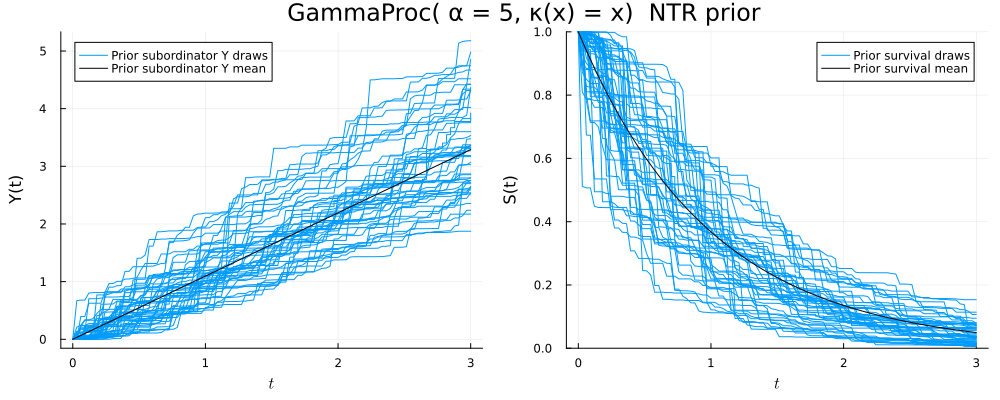

In [4]:
# Plot of prior visualization for elicitation
# Baseline specification
baseline = ExponentialBaseline(1.0)
# Variance modulating hyperparameter controlling dispersion around baseline mean survival
α = 5.0
# Plotting time grid
t =  collect(LinRange(0.0,3.0,100))
# First a priori survival draws
S_tmp = sample_prior_survival(t,α,baseline)
# Underlying subordinator
Y_tmp = -log.(S_tmp)
# Plot 
prior_y_plt = plot(t, Y_tmp, seriestype = :steppost, xlabel = L"t", ylabel = "Y(t)", label = "Prior subordinator Y draws", title="",legend=:topleft)
prior_s_plt = plot(t, S_tmp,seriestype = :steppost, xlabel = L"t", ylabel = "S(t)", label = "Prior survival draws", ylim=(0,1), title="")
for i in 1:49
    S_tmp = sample_prior_survival(t,α,baseline)
    Y_tmp = -log.(S_tmp)
    plot!(prior_y_plt, t, Y_tmp, c=1,label="")
    plot!(prior_s_plt, t, S_tmp,c=1,label="")
end
β = 1.0/log(1.0+1.0/α)
plot!(prior_y_plt, t, (β/α).*t, label="Prior subordinator Y mean", color=:black )
plot!(prior_s_plt, t, exp.(-t), label="Prior survival mean", color=:black )
prior_plot = plot(prior_y_plt,prior_s_plt,size=(1000,400),plot_title="GammaProc( α = $(Int(α)), κ(x) = x)  NTR prior",left_margin = 5.5mm, bottom_margin = 5mm)

### Posterior characterization (conjugacy structure) for NTR priors

We denote possibly censored to the right survival data of size $n>1$ as

$$
\pmb{\mathcal{D}}_n = \left\{ T_i, \delta_i \right\}_{i=1}^n
$$

where

$$
T_i = \min(X_i,C_i), \qquad 
\delta_i = \mathbf{1}\{X_i \le C_i\}, \qquad i=1,\dots,n,
$$

with $X_1,\dots,X_n$ i.i.d. nonnegative random variables representing the event times of interest and $C_1,\dots,C_n$ i.i.d. nonnegative censoring times, independent of the $X_i$'s. We denote the distinct order statistics for observed survival data $\left\{ T_i=t_i\right\}_{i=1}^n$ as
$0 < t_{(1)} < t_{(2)} < \cdots < t_{(k_n)}$, with $k_n $ the observed number of distinct values. At each event time $t_{(k)}$ we define the number of exact observations at time $t_{(k)}$ as
$$
d_k = \sum_{i=1}^n \mathbf{1}\left[ \delta_i=1,\;T_i =  t_{(k)}\right\},
$$
the number of individuals at risk just prior to 
$t_{(k)}$ as
$$
r_k = \sum_{i=1}^n \mathbf{1}\{ T_i \ge t_{(k)}\}.
$$
and the number of individuals at risk just prior to 
$t_{(k)}$ excluding exact observations at $t_{(k)}$ as
$$
r^\star_k = r_k - d_k.
$$
We recall that the Kaplan--Meier estimator of the survival function $S(t)$ is defined as
$$
\widehat{S}_{KM}(t)
= \prod_{k \, : \, t_{(k)} \le t}
\left(1 - \frac{d_k}{r_k}\right),
\qquad t \ge 0,
$$
with the convention that an empty product equals 1.

Let $t_f>t_{(k_n)}$ be a final time up to which we conduct our survival analysis, modeling with a $\text{NTR}(Y)$ prior where the subordinator $Y$ has intensity $\nu(\mathrm{d}w,\mathrm{d}u)$, we denote $\eta_t(\mathrm{d}w)=\nu(\mathrm{d}w,(0,t])$  If 
$$
\eta_{t_0}'( \mathrm{d}w)=\frac{\partial \eta_t(\mathrm{d}w)}{\partial t}\Bigg|_{t=t_0}$$ exists for all $t_0\in(0,t_f]$ then, restricted to $[0,t_f]$, the posterior distribution given survival data $\pmb{\mathcal{D}}$ is $\text{NTR}(\tilde{Y}_{\pmb{\mathcal{D}}})$ with

$$
\tilde{Y}_{\pmb{\mathcal{D}}}(t) = Y^\circ(t) + \sum_{ \left\{ k \, :\, d_k \geq 1 \right\} } W_k \delta_{t_{(k)}}
$$

where, setting $t_{(k_n+1)}=t_f$, $Y^\circ$ is a subordinator with intensity

$$
\nu^\circ (\mathrm{d}w,\mathrm{d}u) = \sum_{k=1}^{k_n+1} e^{- r_k s }\pmb{1}_{\left\{ x\in (t_{(k-1)},t_{(k)}] \right\}}
\nu(\mathrm{d} w,\mathrm{d}u),
$$

the random jump weights $W_k$, corresponding to a jump at fixed location $T_{(k)}$, have probability distribution

\begin{align*}
F_k( \mathrm{d} w) = \frac{ e^{- \tilde{r}_k w}\left( 1-e^{-w} \right)^{d_k} \eta_{t_{(k)}}'(\mathrm{d} w)   }{ \int_0^\infty e^{- \tilde{r}_k w}\left( 1-e^{-w} \right)^{d_k} \eta_{t_{(k)}}'(\mathrm{d} w)  }
\end{align*}

and $\left\{ W_k \right\}_{k=1}^{k_n}\perp Y^\circ$. This result is known as the **posterior chracterization** for NTR models and is akin to conjugacy in Bayesian parametric models not only conceptually but also as a property that provides computational tractability.

Under the simplifyng assumption of $\nu$ being homogeneous and such that

$$
\nu(\mathrm{d} w,(0,t]) =  \kappa(t)\rho(w) \mathrm{d}w
$$

we have that $W_k$ has probability density function

\begin{align*}
f_k(w) = \frac{ e^{- \tilde{r}_k w}\left( 1-e^{-w} \right)^{d_k} \rho(w)  }{ \int_0^\infty e^{- \tilde{r}_k w}\left( 1-e^{-w} \right)^{d_k} \rho ( w ) \mathrm{d}w }.
\end{align*}

**Posterior characterization with Gamma processes workflow for survival analysis**

Furthermore choosing $Y$ to be an homogeneous Gamma process we obtain further simplifications in that

$$
\nu^\circ (\mathrm{d}w,\mathrm{d}u)  = \sum_{k=1}^{k_+1}  \beta \frac{e^{-(\alpha + r_k) w}}{w} \pmb{1}\left\{  {u \in (t_{(k-1)},t_{(k)}]}  \right\} \mathrm{d}w \mathrm{d} \kappa(u),
$$

is a Gamma process intensity, with updated parameter $\alpha$ to $\alpha+r_k$ and the jump weight densities are given by

\begin{align*}
f_k(w) = \frac{ e^{-\left( \alpha + r^\star_k \right)w}\left( 1-e^{-w} \right)^{d_k}w^{-1} }{ \int_0^\infty e^{-\left( \alpha + r^\star_k \right)w}\left( 1-e^{-w} \right)^{d_k}w^{-1}\mathrm{d}w }.
\end{align*}

### Bernstein-von Mises theorem and its asymtotic consequences

Under technical conditions on the intensity $\nu(\mathrm{d}w,\mathrm{d}u)$ underlying a NTR model a Bernstein-von Mises type result holds. This means that in the asymptotic regime where the sample size of survival data tends to infinity then Bayesian credible sets derived from the NTR posterior coincide with frequentist confidence statements based on the Kaplan–Meier estimator. More precisely, let $S_0$ denote the true survival function of the event times $\{X_i\}_{i=1}^n$, which we assume to be continuous, and let $Q_0$ denote the survival function of the censoring times $\{C_i\}_{i=1}^n$. That is $$S_0(t)=\mathbb{P}\left[ X_1 > t\right], \quad Q_0(t)=\mathbb{P}\left[ C_1 > t\right].$$ Let $\kappa_0$ be the cumulative hazard function associated to $S_0$, define
$$
U_0(t) = \int_0^t \frac{ 1 }{ S_0(w)Q_0(w) } \mathrm{d}\kappa_0(w),
$$
and let $B$ be a standard brownian motion in $\mathbb{R}$, then

$$
\mathcal{L}\left(  \sqrt{n} \left( S(\cdot) - \widehat{S}_{KM}^{(n)}(\cdot) \right) \, \big| \, \pmb{\mathcal{D}}_n  \right) \stackrel{d}{\to } S_0(\cdot) B\left( U_0(\cdot) \right)
$$
in the space of right continuous with left limit functions in $[0,t_f)$, endowed with the Skorokhod topology, almost surely with respect to the infinite product probability measure $P^\infty_{1-S_0,1-Q_0}$, which generates the infinite sequence of survival data $\pmb{\mathcal{D}}_\infty$.

So frequentist and Bayesian nonparametric inferences are equivalent in the big sample size limit as it is known that

$$
\sqrt n\left( \hat{S}_{KM}^{(n)}(\cdot)-S_0(\cdot)\right)
\;\xrightarrow{d}\; 
S_0(\cdot) B\left( U_0(\cdot) \right)
$$

and observed approximations based on the survival data are used for inference as

$$
 S_0(\cdot) \approx \widehat{S}_{KM}^{(n)}(\cdot) \exp\left( -n^{-\frac{1}{2}} B\left( \hat{U}_n(\cdot) \right)  \right),
$$
where
$$
\hat{U}_n(t) = n\sum_{i\,:\,T_i \leq t}^n \frac{d_i}{r_i^2},
,
$$
more detail on the frequentist approach derivations is provided in the following section for the Cox model.

The NTR model with a Gamma process subordinator can be shown to satisfy such a Bernstein–von Mises result. Recalling that the Kaplan–Meier estimator is consistent for continuous $S_0$, it follows that the posterior mean and posterior median survival estimators are also consistent. This consistency occurs at the optimal rate, since the $\sqrt{n}$ scaling coincides with the convergence rate for the asymptotic Gaussian distribution of the Kaplan–Meier estimator, which results from a martingale central limit theorem,

For survival datasets of large size, frequentist uncertainty quantification based on the asymptotic Gaussian process distribution yields confidence bands for the true survival function that are asymptotically equivalent to credible bands drawn from the NTR posterior, under technical conditions. The main frequentist confidence bands in the literature are Hall–Wellner, although alternatives such as the equal-precision, also known as Nair, bands exist. For a full treatment of frequentist confidence bands see Klein & Moeschberger 2008. Alternatively, confidence bands can be constructed by bootstrapping the Kaplan–Meier estimator,(Akritas, 1986), yielding bands that are asymptotically equivalent to those derived from the martingale central limit theorem. Later on, we will visualize the Bernstein-von Mises result for our Gamma process workflow.

### Likelihood computation for NTR models

Computation of the likelihood for NTR models with survival data is is provided by

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \psi_{t_{(k)}}\left( r_k  \right) - \psi_{t_{(k-1)}}\left(r_k \right)   \right] \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \int_0^\infty e^{-r^\star_k w}\left(1-e^{-w}\right)^{d_k}
\eta'_{t_{(k)}}( \mathrm{d }w)
\end{align*}

Under the simplifyng assumption of $\nu$ being homogeneous and such that $\nu( \mathrm{d} w,(0,t]) = \kappa(t) \rho(w) \mathrm{d}w $ we have that

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right]\int_0^\infty (1-e^{-r_k w})\rho(w)\mathrm{d}s   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \kappa'\left( t_{(k)} \right) \int_0^\infty e^{-r^\star_k w}\left(1-e^{-w}\right)^{d_k}
 \rho(w)\mathrm{d}w
\end{align*}

**Likelihood computation with Gamma processes workflow for survival analysis**

Using the Laplace exponent formula for Gamma processes and doing a binomial expansion

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \beta \log\left( 1 + \frac{r_k}{\alpha} \right)   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \beta \kappa'\left( t_{(k)} \right) \sum_{j=0}^{d_k-1}\binom{d_k-1}{j}(-1)^{j+1} 
\left[ \int_0^\infty \left(1-e^{- ( r^\star_k + j )  w}\right) \frac{e^{-\alpha w}}{w}\mathrm{d}w - \int_0^\infty \left(1-e^{- ( r^\star_k + j + 1 )  s}\right) \frac{e^{-\alpha w}}{w}\mathrm{d}w  \right]
\\ &= \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \beta \log\left( 1 + \frac{r_k}{\alpha} \right)   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \beta \kappa'\left( t_{(k)} \right) \sum_{j=0}^{d_k-1}\binom{d_k-1}{j}(-1)^{j+1}
\log\left( \frac{\alpha +r^\star_k + j }{\alpha +r^\star_k + j +1 } \right)
\end{align*}

In the particular case that there are no repetitions in the exact observations, i.e. $d_k=1$ for $1\leq k \leq k_n$, then no use of a binomial expansion is necessary and we obtain the simplification

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \beta \log\left( 1 + \frac{r_k}{\alpha} \right)   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} }\beta \kappa'\left( t_{(k)} \right) \log\left(1 + \frac{1}{\alpha+ r^\star_k} \right)
\end{align*}

### Posterior mean survival for NTR models

From the posterior characterization we can obtain the posteror mean survival function, which can be used as an estimator for the survival function of the event times of interest,

\begin{align*}
\hat{S}(t) &= \mathbb{E}\left[  \mathbb{P}\left[ X >t \,|\, Y,\, \pmb{\mathcal{D}}\right] \,|\, \pmb{\mathcal{D}}\ \right]
= \mathbb{E}\left[e^{-Y^\circ(t) }  \,|\, \pmb{\mathcal{D}}\  \right] \prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} } \mathbb{E}\left[e^{-W_k} \,|\, \pmb{\mathcal{D}}\  \right]
\\ &= e^{-\sum_{k=1}^{k_n+1}\left( \psi^\circ_{t\wedge t_{(k)}}(1) - \psi^\circ_{t\wedge t_{(k-1)}}(1)  \right) }
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }\frac{ \int_0^\infty e^{-( r^\star_k + 1)s}\left(1-e^{-w} \right)^{d_k}\eta'_{t_{(k)}}(\mathrm{d} w)  }{ \int_0^\infty e^{- r^\star_k w}\left(1-e^{-w} \right)^{d_k}\eta'_{t_{(k)}}(\mathrm{d}w) }
\end{align*}

where $t_{(k_n+1)}=\infty$ and $\psi^\circ_t(\lambda)= -\log\left( \mathbb{E}\left[ e^{-\lambda Y^\circ(t)} \right] \right)$ is the Laplace exponent of $Y^\circ(t)$.

Again, under the case of $\nu$ being homogeneous and such that $\nu( \mathrm{d} w,(0,t]) = \kappa(t) \rho(w) \mathrm{d} w $ we have the simplification

\begin{align*}
\hat{S}(t) &=  e^{-\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \int_0^\infty e^{-r_k w} (1-e^{- w})\rho(w)\mathrm{d}w }
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }\frac{ \int_0^\infty e^{-( r^\star_k + 1)w}\left(1-e^{-w} \right)^{d_k} \rho(w)\mathrm{d}w }{ \int_0^\infty e^{- r^\star_k w}\left(1-e^{-w} \right)^{d_k}\rho(w)\mathrm{d}w };
\end{align*}

and for the Gamma process case in particular we get

\begin{align*}
\hat{S}(t) &=  e^{-\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \log\left(1 +\frac{1}{\alpha+r_k} \right)}
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }\frac{ \sum_{j=0}^{d_k-1}\binom{d_k-1}{j}(-1)^{j-1}
\log\left( \frac{\alpha +r^\star_k + j +1 }{\alpha +r^\star_k + j + 2 } \right)
 }{ \sum_{j=0}^{d_k-1}\binom{d_k-1}{j}(-1)^{j-1}
\log\left( \frac{\alpha +r^\star_k + j }{\alpha +r^\star_k + j + 1 } \right) };
\end{align*}

We simulate 333, independent, Weibull survival times without censoring. Using the prior specification described above, we fit a NTR model and compare the Kaplan–Meier estimator with the posterior mean survival curve. This comparison illustrates the asymptotic agreement between the two procedures.

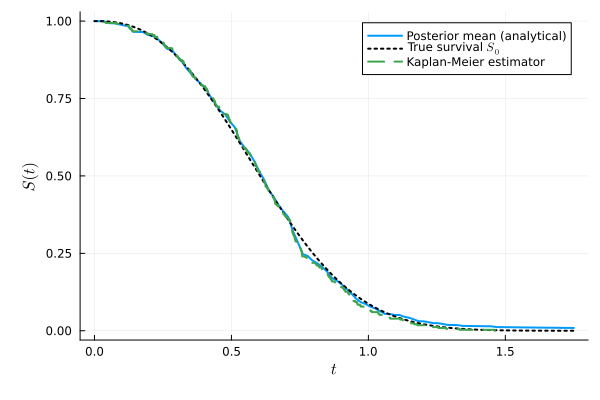

In [5]:
# Implementation of Weibull simulation study and posterior mean illustration
# Synthetic data generation
n = 333
λ= 0.7 # Weibull rate parameter
k = 2.5 # Weibull shape parameter
T = rand( Weibull(k,λ), n)
δ = zeros(Int64,n) .+ 1 # no censoring
# Compute Kaplan-Meier estimator via Survival package
km = fit(KaplanMeier, T, δ)
# NTR survival data struct
data = SurvivalData(T,δ)
# NTR model struct
model = NeutralToTheRightModel( α, baseline, data)
# Plotting time grid updated for better visualization
t =  collect(LinRange(0.0,1.75,100))
# Posterior mean survival computation
Sm = mean_posterior_survival(t,model)
# Posterior computations plot
post_mean_plot = plot( t, Sm, xlabel="\$t\$", ylabel="\$S(t)\$", linewidth=2, label="Posterior mean (analytical)",left_margin = 5.5mm, bottom_margin = 5mm)
plot!( t, ccdf.( Weibull(k,λ), t), color=:black, linestyle=:dot, linewidth=2, label="True survival \$S_0\$")
plot!(km.events.time,km.survival,seriestype = :steppost, linestyle=:dash, c=3, linewidth=2,label="Kaplan-Meier estimator")

### Posterior simulation of NTR survival functions

From the posterior characterization of the NTR model, we have that simulation of posterior survival draws is feasible by drawing

$$
\tilde{S}_{\pmb{\mathcal{D}}}(t) = \exp\left( -\tilde{Y}_{\pmb{\mathcal{D}}}(t) \right) 
$$

It is seen from the posterior characterization that in order to draw simulations of $\tilde{Y}_{\pmb{\mathcal{D}}}$ in $[0,t_f]$ we only need to:

1) Draw Gamma processes in $(t_{(k-1)},t_{(k)}]$ with parameters $\kappa$, $\beta_\alpha$ and $\alpha^\circ=\alpha+r_k$.

2) Draw random weights, corresponding to fixed jump location $t_{(k)}$,  $W_k\sim\mathcal{L}(f_k)$.

For the random weights in our Gamma process workflow we use an efficient acceptance-rejection sampler in the sense that the probability of acceptance goes to one as $r_k^\star$ goes to infinity, provided that $\frac{1}{n}\sum_{i=1}^n \delta_i$ converges to a positive limit. Complexity of the draw for random weights depends on the associated jump location $t_{(k)}$ corresponds to repeated exact observations on the survival data or not. Details on the acceptance-rejection scheme follow next.

##### No repetitions case
Let the kernel of $f_k$ be denoted by
$$
f_k^{\text{ker}}= e^{-\left( \alpha + r^\star_k \right)s}\left( 1-e^{-s} \right)s^{-1}  
$$
Use proposal distribution $\text{Exp}(\alpha+r_k^\star)$ and accept a draw $V$ from it if for an independent $U\sim\text{Uniform}(0,1)$
$$
\frac{1-e^{-V}}{V}\leq U.
$$ 

##### Repetitions case
In this case
$$
f_k^{\text{ker}}= e^{-\left( \alpha + r^\star_k \right)s}\left( 1-e^{-s} \right)^{d_k}s^{-1}  
$$
and we use proposal distribution $\text{Gamma}(d_k,\alpha + r_k^\star)$ and accept a draw $V$ from it if for an independent $U\sim\text{Uniform}(0,1)$
$$
\left( \frac{1-e^{-V}}{V} \right)^{d_k}\leq U.
$$ 

We draw posterior samples and construct credible bands which illustrate the Bernsetin-von Mises theorem for the NTR model Gamma process workflow.

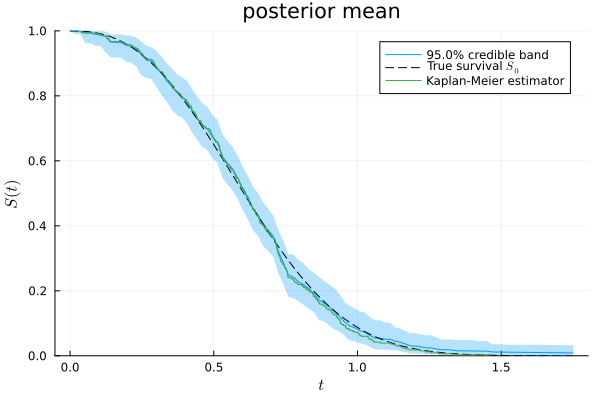

In [6]:
# Posterior credible band computation and illustration
NTR_band = posterior_credible_band(0.05,3000,t,model)
# Plot
post_draws_plot = plot( NTR_band)
plot!( t, ccdf.( Weibull(k,λ), t), color=:black,linestyle=:dash, label="True survival \$S_0\$")
plot!(km.events.time,km.survival,seriestype = :steppost,label="Kaplan-Meier estimator")

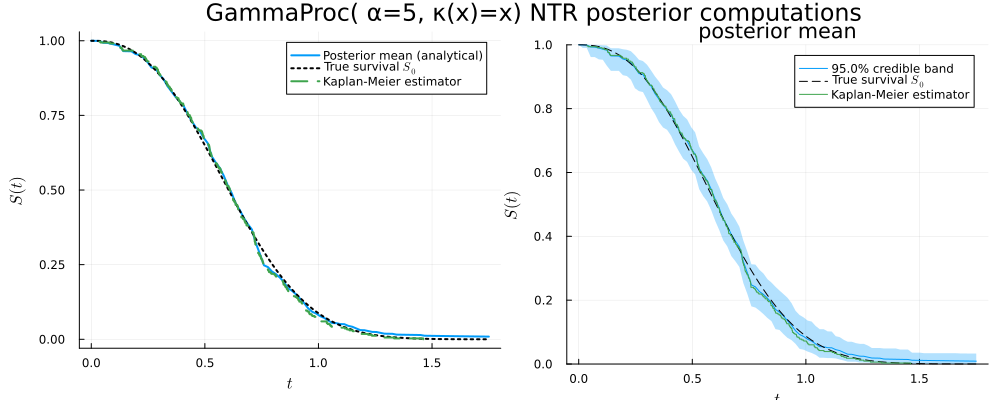

In [7]:
# NTR posterior computations illustration
posterior_plot = plot(post_mean_plot,post_draws_plot,size=(1000,400),plot_title="GammaProc( α=5, κ(x)=x) NTR posterior computations")

We illustrate the Bernstein-von Mises theorem, discussed above, for our Gamma process NTR model workflow.

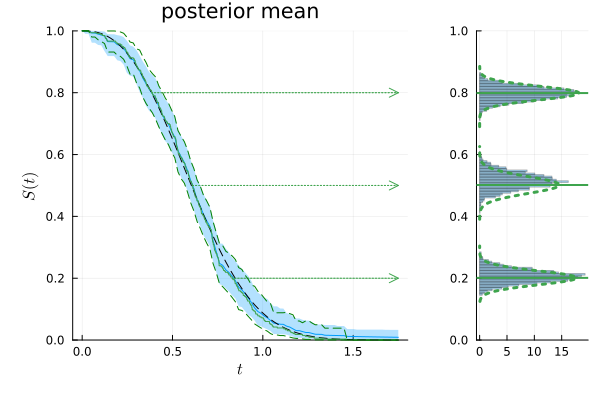

In [8]:
# Illustration of Bernstein-von Mises result with data size 333
# Sample 3000 posterior survival curves
Sdraws = sample_posterior_survival(3000,t,model)
# Sample 3000 asymptotic Gaussian processes
km_eval(km, q::AbstractVector{<:Real}) = step_eval(km.events.time, km.survival, q; left = 1.0) # Auxilliary evaluation of Kaplan-Meier estimator as a function
KMeval = km_eval(km, t)
Ut = Uestim(t,data)
Un(v) = step_eval(t,Ut,v;left=0.0)
Sfreqdraws = Sfreq_mat(3000,n,t,KMeval,Un)
freq_band = credible_band( t, 0.05, Sfreqdraws)
# Quantile levels
v1 = 0.8
v2 = 0.5
v3 = 0.2
# Index for emirical quantile computation
KM_i_1 = findmin( abs.( km.survival .- v1))[2]
KM_i_2 = findmin( abs.( km.survival .- v2))[2]
KM_i_3 = findmin( abs.( km.survival .- v3))[2]
# Empirical quantiles
t_1 = km.events.time[KM_i_1]
t_2 = km.events.time[KM_i_2]
t_3 = km.events.time[KM_i_3]
# Empirical quantiles in posterior simulation grid
t_p_1 = findmin( abs.( t .- t_1))[2]
t_p_2 = findmin( abs.( t .- t_2))[2]
t_p_3 = findmin( abs.( t .- t_3))[2]
# Comute time grids for histograms
l_tmp_1 = minimum(Sdraws[:,t_p_1])
u_tmp_1 = maximum(Sdraws[:,t_p_1])
t_tmp_1 = LinRange(l_tmp_1-0.02,u_tmp_1+0.02,100)
l_tmp_2 = minimum(Sdraws[:,t_p_2])
u_tmp_2 = maximum(Sdraws[:,t_p_2])
t_tmp_2 = LinRange(l_tmp_2-0.02,u_tmp_2+0.02,100)
l_tmp_3 = minimum(Sdraws[:,t_p_3])
u_tmp_3 = maximum(Sdraws[:,t_p_3])
t_tmp_3 = LinRange(l_tmp_3-0.02,u_tmp_3+0.02,100)
# Plot
p1 = plot( NTR_band, xlabel="\$t\$", ylabel="\$S(t)\$", ylim=(0,1), fillalpha=0.3, label="NTR posterior mean survival \n with 95% credible band",size=(600,400))
plot!(p1, t, ccdf.( Weibull(k,λ), t), color=:black,linestyle=:dash, label="True survival")
plot!(p1, km.events.time, km.survival,seriestype = :steppost,label="Kaplan-Meier estimator", legend=false)
plot!(p1, [t_1,1.75],  [v1,v1], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, [t_2,1.75],  [v2,v2], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, [t_3,1.75],  [v3,v3], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, t, freq_band.u, color=:green, linestyle=:dash)
plot!(p1, t, freq_band.d, color=:green, linestyle=:dash)
p2 = histogram(Sdraws[:,t_p_1],normalize=true, alpha = 0.3, linecolor = :transparent,label="",orientation=:h, ylim = (0,1))
plot!( p2, pdf(Normal(km.survival[KM_i_1], sqrt( ccdf( Weibull(k,λ), t_1)*(1-ccdf( Weibull(k,λ), t_1))/n ) ), t_tmp_1), t_tmp_1,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_1]], c=3, label="", linewidth=2 )
histogram!(p2, Sdraws[:,t_p_2],normalize=true, alpha = 0.3, linecolor = :transparent, c=1, label="",orientation=:h)
plot!( p2, pdf(Normal(km.survival[KM_i_2], sqrt( ccdf( Weibull(k,λ), t_2)*(1-ccdf( Weibull(k,λ), t_2))/n ) ), t_tmp_2), t_tmp_2,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_2]], c=3, label="", linewidth=2 )
histogram!(p2, Sdraws[:,t_p_3],normalize=true, alpha = 0.3, linecolor = :transparent, c=1, label="",orientation=:h)
plot!( p2, pdf(Normal(km.survival[KM_i_3], sqrt( ccdf( Weibull(k,λ), t_3)*(1-ccdf( Weibull(k,λ), t_3))/n ) ), t_tmp_3), t_tmp_3,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_3]], c=3, label="", linewidth=2 )
l = @layout [a b{0.25w}]
plot(p1,p2,layout=l,left_margin = 5.5mm, bottom_margin = 5mm)

We further illustrate the consistency and BvM result of our NTR modeling framework by increasing the survival data size to 3333.

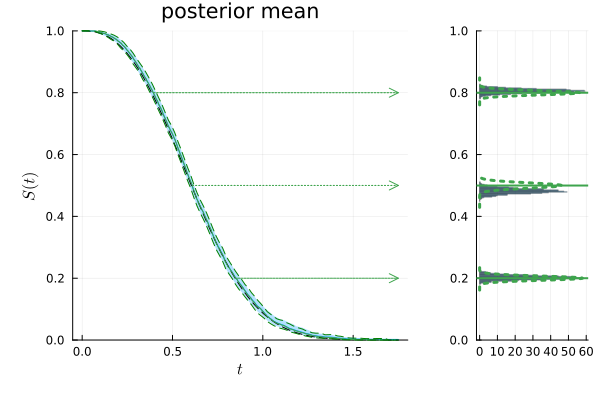

In [9]:
# Illustration of Bernstein-von Mises result with data size 3333
# Synthetic data generation
#Random.seed!(1234)
n = 3333
T = rand( Weibull(k,λ), n)
δ = zeros(Int64,n) .+ 1 # no censoring
# Compute Kaplan-Meier estimator via Survival package
km = fit(KaplanMeier, T, δ)
KMeval = km_eval(km, t)
# NTR survival data struct
data = SurvivalData(T,δ)
# NTR model struct
model = NeutralToTheRightModel( α, baseline, data)
# Posterior simulation of survival curves
NTR_band = posterior_credible_band(0.05,3000,t,model)
Sdraws = sample_posterior_survival(3000,t,model)
# Sample 3000 asymptotic Gaussian processes
Ut = Uestim(t,data)
Un(v) = step_eval(t,Ut,v;left=0.0)
Sfreqdraws = Sfreq_mat(3000,n,t,KMeval,Un)
freq_band = credible_band( t, 0.05, Sfreqdraws)
# Quantile levels
v1 = 0.8
v2 = 0.5
v3 = 0.2
# Index for emirical quantile computation
KM_i_1 = findmin( abs.( km.survival .- v1))[2]
KM_i_2 = findmin( abs.( km.survival .- v2))[2]
KM_i_3 = findmin( abs.( km.survival .- v3))[2]
# Empirical quantiles
t_1 = km.events.time[KM_i_1]
t_2 = km.events.time[KM_i_2]
t_3 = km.events.time[KM_i_3]
# Empirical quantiles in posterior simulation grid
t_p_1 = findmin( abs.( t .- t_1))[2]
t_p_2 = findmin( abs.( t .- t_2))[2]
t_p_3 = findmin( abs.( t .- t_3))[2]
# Comute time grids for histograms
l_tmp_1 = minimum(Sdraws[:,t_p_1])
u_tmp_1 = maximum(Sdraws[:,t_p_1])
t_tmp_1 = LinRange(l_tmp_1-0.02,u_tmp_1+0.02,100)
l_tmp_2 = minimum(Sdraws[:,t_p_2])
u_tmp_2 = maximum(Sdraws[:,t_p_2])
t_tmp_2 = LinRange(l_tmp_2-0.02,u_tmp_2+0.02,100)
l_tmp_3 = minimum(Sdraws[:,t_p_3])
u_tmp_3 = maximum(Sdraws[:,t_p_3])
t_tmp_3 = LinRange(l_tmp_3-0.02,u_tmp_3+0.02,100)
# Plot
p1 = plot( NTR_band, xlabel="\$t\$", ylabel="\$S(t)\$", ylim=(0,1), fillalpha=0.3, label="NTR posterior mean survival \n with 95% credible band",size=(600,400))
plot!(p1, t, ccdf.( Weibull(k,λ), t), color=:black,linestyle=:dash, label="True survival")
plot!(p1, km.events.time, km.survival,seriestype = :steppost,label="Kaplan-Meier estimator", legend=false)
plot!(p1, [t_1,1.75],  [v1,v1], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, [t_2,1.75],  [v2,v2], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, [t_3,1.75],  [v3,v3], c=3, linestyle=:dot, arrow = :arrow)
plot!(p1, t, freq_band.u, color=:green, linestyle=:dash)
plot!(p1, t, freq_band.d, color=:green, linestyle=:dash)
p2 = histogram(Sdraws[:,t_p_1],normalize=true, alpha = 0.3, linecolor = :transparent,label="",orientation=:h, ylim = (0,1))
plot!( p2, pdf(Normal(km.survival[KM_i_1], sqrt( ccdf( Weibull(k,λ), t_1)*(1-ccdf( Weibull(k,λ), t_1))/n ) ), t_tmp_1), t_tmp_1,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_1]], c=3, label="", linewidth=2 )
histogram!(p2, Sdraws[:,t_p_2],normalize=true, alpha = 0.3, linecolor = :transparent, c=1, label="",orientation=:h)
plot!( p2, pdf(Normal(km.survival[KM_i_2], sqrt( ccdf( Weibull(k,λ), t_2)*(1-ccdf( Weibull(k,λ), t_2))/n ) ), t_tmp_2), t_tmp_2,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_2]], c=3, label="", linewidth=2 )
histogram!(p2, Sdraws[:,t_p_3],normalize=true, alpha = 0.3, linecolor = :transparent, c=1, label="",orientation=:h)
plot!( p2, pdf(Normal(km.survival[KM_i_3], sqrt( ccdf( Weibull(k,λ), t_3)*(1-ccdf( Weibull(k,λ), t_3))/n ) ), t_tmp_3), t_tmp_3,linewidth=3, linestyle=:dot, c=3,label="")
hline!( [km.survival[KM_i_3]], c=3, label="", linewidth=2 )
l = @layout [a b{0.25w}]
plot(p1,p2,layout=l, left_margin = 5.5mm, bottom_margin = 5mm)

## Cox-NTR model

We can consider the inclussion of covariates in NTR based models. Denote such covariates as $\pmb{Z}$ for $T$ a possibly censored to the right random variable. The Cox regression model for NTR Cox-baseline is determined by covariate conditional survival function
$$
S(t;\pmb{Z})= \exp\left( -e^{g(\pmb{c},\pmb{Z})}Y(t)  \right)
$$

We will draw covariate dependent survival data from a Weibull Cox regression model.

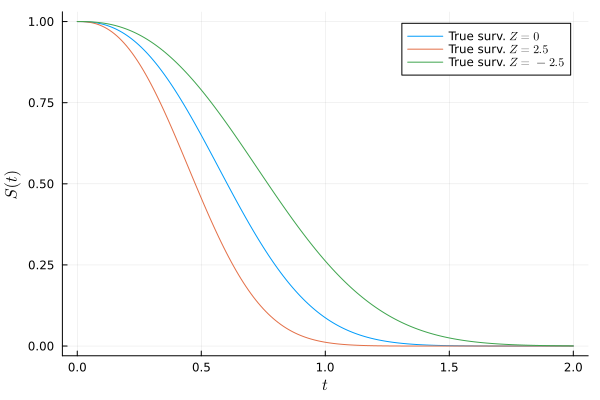

In [10]:
# Plot true survival curves of Weibull simulation study with covariates
# We will draw covariate dependent Weibull samples from
λ= 0.7 # Weibull rate parameter
k = 2.5 # Weibull shape parameter
b = 0.3 # Cox regression coefficient
t = collect(0.0:0.01:2.0)
plot(t, ccdf.( Weibull( k,λ), t), xlabel="\$t\$", ylabel="\$S(t)\$", label="True surv. \$Z=0\$" ) 
plot!(t, ccdf.( Weibull( k,λ/exp(b*2.0/k)), t), label="True surv. \$Z=2.5\$" ) 
plot!(t, ccdf.( Weibull( k,λ/exp(-b*2.0/k)), t), label="True surv. \$Z=-2.5\$" ) 

We observe how the Cox covariate dependence structure drives survival data away from the baseline distribution.

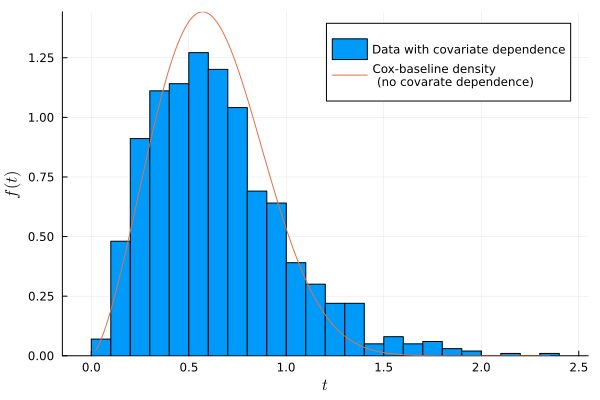

In [11]:
# Implementation of Weibull simulation study with covariates and histogram illustration
# Covariate distribution
Dz = MixtureModel(Normal[
   Normal(-2.5, 1.2),
   Normal(2.5, 1.2),
   Normal(0.0, 1.0)], [1/3, 1/3, 1/3])
# Quantiles of covariate distribution
q_v = quantile(Dz,[1/3,2/3,])
# Synthetic data generation
m = 999
Z = [ [rand(Dz)] for _ in 1:m ]
randXgivenZ(z::Vector{Float64};b::Float64,k::Float64,λ::Float64) = rand(Weibull(k, λ / exp(b * z[1] / k)))
T = [ randXgivenZ(z;b,k,λ) for z in Z ]
δ = zeros(Int64,m) .+ 1
histogram(T,normalize=true,label="Data with covariate dependence", xlabel="\$t\$", ylabel="\$f(t)\$")
plot!( collect(minimum(T):0.01:maximum(T)), pdf.(Weibull(k,λ),collect(minimum(T):0.01:maximum(T))), label="Cox-baseline density \n (no covarate dependence)" )

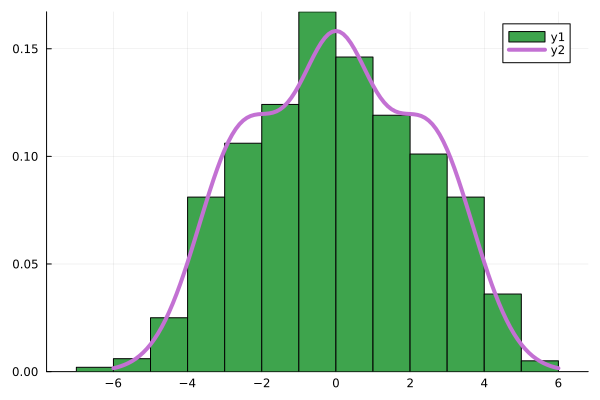

In [12]:
# Covariate histogram
histogram([ z[1] for z in Z], c=3, normalize=true)
plot!( collect(-6:0.1:6), pdf.(Dz,collect(-6:0.1:6)),c=4, linewidth=4 )

### Posterior characterization (conjugacy structure) for Cox NTR priors

For the Cox regression setting we define
\begin{align*}
h^{(e)}_k(\pmb{c}) &= \sum_{\{i\,:\, t_i = t_{(k)},\, \delta_i=1 \}} g(\pmb{c},\pmb{Z}_i), \quad \bar{h}^{(c)}_k(\pmb{c}) = \sum_{ \{i\,:\, t_i = t_{(k)},\, \delta_i=0 \} }g(\pmb{c},\pmb{Z}_i)
\\ 
\bar{h}^{(e)}_k(\pmb{c}) &= \sum_{i=k}^{k_n} h^{(e)}_i(\pmb{c},\widehat{\pmb{Z}}), \quad \hphantom{} \bar{h}^{(c)}_k(\pmb{c}) = \sum_{i=k}^{k_n} h^{(c)}_i(\pmb{c},\widehat{\pmb{Z}}).
\end{align*}
So the quantities related to the numbers of at risk patients become
\begin{align*}
h_k(\pmb{c})=\bar{h}^{(c)}_k(\pmb{c})+\bar{h}^{(e)}_k(\pmb{c}), &\quad h^\star_k(\pmb{c})=\bar{h}^{(c)}_k(\pmb{c})+\bar{h}^{(e)}_{k+1}(\pmb{c})
\end{align*}
where $\bar{h}^{(e)}_{k_n+1}(\pmb{c})=0$.

The posterior distribution of the Cox-baseline $Y$ is determined by

\begin{align*}
\mathbb{E}\left[  e^{-\lambda Y(t) } \,\Big| \pmb{\mathcal{D}} \right]
= \exp\left( -\sum_{k=1}^{k_n+1} \int_{ (t_{(k-1)}}^{t_{(k)}} \int_0^\infty (1-e^{-\lambda w})e^{- h_k(\pmb{c})w} \nu(\mathrm{d}w,\mathrm{d}u)  \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \frac{ \int_0^\infty e^{- \left( \lambda + h_k^\star(\pmb{c}) \right) w } \prod_{ \{ l\,:\, t_l= t_{(k)},\,  \delta_l = 1 \} } \left( 1 - e^{-g\left(\pmb{c},\pmb{Z}_l \right) w } \right) \eta'_{t_{(k)}}( \mathrm{d} w) }{  \int_0^\infty e^{-  h_k^\star(\pmb{c})w } \prod_{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} } \left( 1 - e^{-g\left(\pmb{c},\pmb{Z}_l \right) w } \right) \eta'_{t_{(k)}}( \mathrm{d} w) }
\end{align*}

Consider a posteriori the survival time $X^{(\text{new})}$ corresponding to a new patient with associated covariate vector $\pmb{Z}^{(\text{new})}$. The posterior distribution of $g(\pmb{c},\pmb{Z}^{(\text{new})})Y$ in $(0,t_f]$ is characterized by

\begin{align*}
\mathbb{E}\left[  e^{-\lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) Y(t) } \,\Big| \pmb{\mathcal{D}} \right]
= \exp\left( -\sum_{k=1}^{k_n+1} \int_{t_{(k-1)}}^{t_{(k)}} \int_0^\infty (1-e^{-\lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) w})e^{- h_k(\pmb{c})w} \nu( \mathrm{d} w, \mathrm{d}u) \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \frac{ \int_0^\infty e^{- \left( \lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) + h_k^\star(\pmb{c}) \right)w } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-g\left(\pmb{c},\pmb{Z}_l \right)w } \right) \eta'_{t_{(k)}}( \mathrm{d} w) }{  \int_0^\infty e^{-  h_k^\star(\pmb{c})w } \underset{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} }{ \prod } \left( 1 - e^{-g_l\left(\pmb{c},\pmb{Z}_l \right)w } \right) \eta'_{t_{(k)}}(\mathrm{d} w) }
\end{align*}

so we obtain with changes of variables $m(s,x)= \left( g(\pmb{c},\pmb{Z}^{(\text{new})})s,x\right)$, $m(s)= g(\pmb{c},\pmb{Z}^{(\text{new})})s$ 

\begin{align*}
\mathbb{E}\left[  e^{-\lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) Y(t) } \,\Big| \pmb{\mathcal{D}}_{\hat{\pmb{Z}}} \right]
= \exp\left( -\sum_{k=1}^{k_n+1} \int_{t_{(k-1)}}^{t_{(k)}} \int_0^\infty (1-e^{-\lambda w})e^{- \frac{ h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})}) } w} \nu\circ m^{-1}\left( \mathrm{d}w,\mathrm{d}u \right) \right)
\underset{ \{ k \,:\, d_k \geq 1 \} }{\prod} \frac{ \int_0^\infty e^{- \left( \lambda + \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)w } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-\frac{ g\left(\pmb{c},\pmb{Z}_l \right)}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w } \right) \eta'_{t_{(k)}} \circ m^{-1} (\mathrm{d}w) }{  \int_0^\infty e^{-  \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }w } \underset{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} }{\prod} \left( 1 - e^{- \frac{ g_l\left(\pmb{c},\pmb{Z}_l \right) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }w } \right) \eta'_{t_{(k)}}\circ m ^{-1}(\mathrm{d}w)  }
\end{align*}

so a posteriori $Y_{\pmb{c},\pmb{Z}^{(\text{new})}} =  g(\pmb{c},\pmb{Z}^{(\text{new})}) Y $ has distribution coinciding with

$$
\tilde{Y}_{\pmb{c},\pmb{Z}^{(\text{new})},\pmb{\mathcal{D}}}(t) = Y_{\pmb{c},\pmb{Z}^{(\text{new})}}^\circ(t) + \sum_{ \left\{ k \, :\, d_k \geq 1 \right\} } W_k \delta_{t_{(k)}}
$$

where $Y_{\pmb{c},\pmb{Z}^{(\text{new})}}^\circ$ is a subordinator with intensity

$$
\nu^\circ (\mathrm{d} w, \mathrm{d}u) = \sum_{k=1}^{k_n+1} e^{-\left( \frac{  h_k(\pmb{c}) }{ g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)}\right)w }\pmb{1}_{\left\{ x\in (t_{(k-1)},t_{(k)}] \right\}}
\nu\circ m^{-1}( \mathrm{d}w,\mathrm{d}u),
$$

the random jump weights $W_k$, corresponding to a jump at fixed location $t_{(k)}$, have probability density function, with respect to dominating measure $\eta'_{t_{(k)}}\circ m ^{-1}$,

\begin{align*}
f_{k,\pmb{Z}^{(new)}}(w) = \frac{ e^{-\left( \frac{ h_k^\star(\pmb{c}) }{g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)} \right)w}\prod_{ \{ l \,:\, t_l= t_{(k)}\, , \delta_l = 1 \} }\left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)} \right) w} \right)  }{ \int_0^\infty e^{-\left( \frac{ h_k^\star(\pmb{c}) }{g\left(\pmb{c},\pmb{Z}^{(\text{new})} \right)} \right)w}\prod_{ \{ l \,:\, t_l= t_{(k)}\, , \delta_l = 1 \} }\left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)} \right)w} \right) \eta'_{t_{(k)}}\circ m ^{-1}( \mathrm{d}w) }.
\end{align*}

and $\left\{ W_k \right\}_{k=1}^{k_n}\perp Y^\circ$.

Under the simplifyng assumption of $\nu$ being homogeneous and such that

$$
\nu(w,(0,t]) = \kappa(t)\rho(w)
$$

\begin{align*}
\mathbb{E}\left[  e^{-\lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) Y(t) } \,\Big| \pmb{\mathcal{D}} \right]
&= \exp\left( - \sum_{k=1}^{k_n+1} \left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right)\int_0^\infty (1-e^{-\lambda s})e^{- \frac{ h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})}) } s} \rho\circ m^{-1}\left( \mathrm{d}s \right) \right)
\\ & \quad \times \underset{ \{ k \,:\, d_k \geq 1 \} }{\prod} \frac{ \int_0^\infty e^{- \left( \lambda + \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-\frac{ g\left(\pmb{c},\pmb{Z}_l \right)}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } s } \right) \rho \circ m^{-1} (\mathrm{d}s) }{  \int_0^\infty e^{-  \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \underset{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} }{\prod} \left( 1 - e^{- \frac{ g_l\left(\pmb{c},\pmb{Z}_l \right) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \right) \rho\circ m ^{-1}(\mathrm{d}s)  }
\end{align*}

and we have that

\begin{align*}
f_{k,\pmb{Z}^{(new)}}(\mathrm{d}s) = \frac{ e^{-\left( \frac{ h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right)s}\prod_{ \{ l \,:\, t_l= t_{(k)}\, , \delta_l = 1 \} }\left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) s} \right) \rho \circ m^{-1} (\mathrm{d}s)  }{ \int_0^\infty e^{-\left( \frac{ h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right)u}\prod_{ \{ l \,:\, t_l= t_{(k)}\, , \delta_l = 1 \} }\left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right)u} \right) \rho \circ m^{-1}(u) \mathrm{d}u }.
\end{align*}

**Posterior characterization with Gamma processes workflow for survival analysis**

Furthermore choosing the Cox-baseline $Y$ to be an homogeneous Gamma process we obtain further simplifications in that

\begin{align*}
\mathbb{E}\left[  e^{-\lambda g(\pmb{c},\pmb{Z}^{(\text{new})}) Y(t) } \,\Big| \pmb{\mathcal{D}} \right]
=& \exp\left( - \beta \sum_{k=1}^{k_n+1} \left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \int_0^\infty (1-e^{-\lambda s})e^{- \frac{ \alpha + h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})}) } s} s^{-1} \mathrm{d}s \right)
\\ & \quad \times \underset{ \{ k \,:\, d_k \geq 1 \} }{\prod} \frac{ \int_0^\infty e^{- \left( \lambda + \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-\frac{ g\left(\pmb{c},\pmb{Z}_l \right)}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } s } \right) \rho \circ m^{-1} (\mathrm{d}s) }{  \int_0^\infty e^{-  \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \underset{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} }{\prod} \left( 1 - e^{- \frac{ g_l\left(\pmb{c},\pmb{Z}_l \right) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \right) \rho\circ m ^{-1}(\mathrm{d}s)  }
\end{align*}
from which
$$
\nu^\circ (\mathrm{d}s,\mathrm{d}x) \Big|_{x \in (t_{(k-1)},t_{(k)}]}  =  \beta \frac{e^{-\left(\frac{\alpha + h_k(\pmb{c})}{ g\left(\pmb{c},\pmb{Z}^{(\text{new})} \right) } \right) s}}{s} \mathrm{d}s \mathrm{d} \kappa(x),
$$

is a Gamma process intensity, with updated parameter $\alpha$ to $(\alpha+h_k)/g\left(\pmb{c},\pmb{Z}^{(\text{new})} \right)$ 


and the jump weight densities are given by

\begin{align*}
f_{k,\pmb{Z}^{(new)}}(s) \propto e^{-\left( \frac{ \alpha + h^\star_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right)s} s^{-1} \underset{ \{ l \,:\, t_l= t_{(k)}\, , \delta_l = 1 \}  }{\prod}\left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) s} \right).
\end{align*}

In case that there are no repetitions of exact observations we obtain

\begin{align*}
f_{k,\pmb{Z}^{(new)}}(s) \propto e^{-\left( \frac{ \alpha + h_k(\pmb{c}) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right)s} \left( 1-e^{-\left(\frac{ g(\pmb{c},\pmb{Z}_l) }{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) s} \right)s^{-1} .
\end{align*}

### Bernstein-von Mises theorem and its asymtotic consequences

Again, a Bernstein-von Mises type result holds for the Cox-NTR under some technical regularity conditions.


Let $\hat{\pmb{c}}_{ML}^{(n)}$ be the maximum (partial) likelihood estimator given by optimizing the Cox partial likelihood

\begin{align*}
L_n(\pmb{c}) 
&= \prod_{k=1}^{k_n} \prod_{\{i\,:\, t_i = t_{(k)},\, \delta_i=1 \}}
\frac{ \exp(\pmb{c}' \pmb{Z}_i) }{ \frac{1}{n}h_k(\pmb{c}) } = \prod_{k=1}^{k_n} \left( \frac{n}{h_k(\pmb{c})} \right)^{d_k} \prod_{\{i\,:\, t_i = t_{(k)},\, \delta_i=1 \}} \exp(\pmb{c}' \pmb{Z}_i).
\end{align*}

And let 

$$
\hat{S}_{\text{BR}}^{(n)}(t;\pmb{Z}) = 
\exp\left(
- g\left(\hat{\pmb{c}}_{ML}^{(n)}), \pmb{Z} \right)
\hat{\kappa}_{\text{BR}}^{(n)}(t)
\right), \qquad \text{where } \hat{\kappa}_{\text{BR}}^{(n)}(t)= 
\sum_{i\,:\, T_i \le t}
\frac{d_i}
{\sum_{j\,:\,T_j\ge T_i}
 g\left( \hat{\pmb{c}}_{ML}^{(n)} , \pmb{Z}_j \right)}.
$$

be the so called Breslow estimator. Denote

\begin{align*}
S_0(t,\pmb{c}) &= \mathbb{E}\left[ \exp(\pmb{c}'\pmb{Z}_1) \pmb{1}\left\{ T_1 >t \right\} \right],
&
U_0(t,\pmb{c}) &= \int_0^t \frac{ 1 }{  S_0(w,\pmb{c}) } \mathrm{d}\kappa_0(w),
\\
\pmb{S}_1(t,\pmb{c}) &=  \mathbb{E}\left[ \pmb{Z}_1 \exp(\pmb{c}' \pmb{Z}_1)   \pmb{1}\left\{ T_1 >t \right\} \right],
&
\pmb{V}_0(t,\pmb{c}) &= \int_0^t  \frac{ \pmb{S}_1(w,\pmb{c}) }{  S_0(w,\pmb{c}) }  \mathrm{d}\kappa_0(w)
\\
\pmb{S}_2(t,\pmb{c}) &= \mathbb{E}\left[ \pmb{Z}_1 \pmb{Z}_1' \exp(\pmb{c}'\pmb{Z}) \pmb{1}\left\{ T_1 >t \right\} \right]
&
I(\pmb{c}) &= \int_0^{t_f} \left(  \pmb{S}_2(w,\pmb{c}) - \frac{ \pmb{S}_1(w,\pmb{c})  \pmb{S}_1'(w,\pmb{c}) }{  S_0(w,\pmb{c}) }  \right)  \mathrm{d}\kappa_0(w)
\end{align*}

Under suitable regularity conditions on the prior and the baseline hazard, it is satisfied that
$$
\mathcal{L}\!\left( \sqrt{n}\left( S(\cdot) - \widehat{S}_{BR}^{(n)}(\cdot) \right),\;
\sqrt{n}\left( \mathbf{c} - \hat{\pmb{c}}_{ML}^{(n)} \right)
\;\middle|\; \mathbf{\mathcal{D}}_n
\right)
\;\xrightarrow{d}\; \left( S_0(\cdot) \left( B\left( U_0(\,\cdot\,;\pmb{c}_0) \right)  \right)  - \pmb{V}_0'(\, \cdot \, ; \pmb{c}_0)\pmb{I}(\mathbf{c}_0)^{-\frac{1}{2}}\pmb{W},\, 
\pmb{I}(\mathbf{c}_0)^{-\frac{1}{2}}\pmb{W} \right)
$$
almost surely under the true data-generating law. So frequentist and Bayesian nonparametric inferences are again equivalent for the Cox model in the big sample size limit as it is also known that

$$
\left(
\sqrt n\left( \hat{S}_{BR}^{(n)}(\cdot)-S_0(\cdot)\right),
\sqrt n\left(\hat{\pmb{c}}_{ML}^{(n)} -\pmb{c}_0\right)
\right)
\;\xrightarrow{d}\; 
\left(
S_0(\cdot) \left( \pmb{V}_0'(\, \cdot \, ; \pmb{c}_0)\pmb{I}(\mathbf{c}_0)^{-\frac{1}{2}}\pmb{W}
- B\left( U_0(\,\cdot\,;\pmb{c}_0) \right)
\right),
\;
- I(\mathbf c_0)^{-1/2}\mathbf W
\right).
$$

In this cell we present theory for computation of frequentist asymptotics and Bernstein-von Mises theorem illustration.

Given a sample of survival data we use observed version of such quantities, specifically

\begin{align*}
\hat{S}_{n,0}(t) &= \frac{1}{n}\sum_{i\,:\, T_i \geq t } g\left( \hat{\pmb{c}}_{ML}^{(n)}, \pmb{Z}_i \right) ,
&
\hat{U}_n(t ) &= \int_0^t \frac{ 1 }{  \hat{S}_{n,0}(w,\hat{\pmb{\pmb{c}}}_{ML}^{(n)}) } \mathrm{d}\hat{\kappa}_{\text{BR}}(w)
= \frac{1}{n}\sum_{i\,:\,T_i \leq t}^n \frac{d_i}{\hat{\pmb{S}}_{n,0}(T_i,\hat{\pmb{c}}_{ML}^{(n)})^2},
\\
\hat{\pmb{S}}_{n,1}(t) &=  \frac{1}{n}\sum_{i\,:\, T_i \geq t } \nabla_{\pmb{c}}g\left( \hat{\pmb{c}}_{ML}^{(n)}, \pmb{Z}_i \right) ,
&
\hat{\pmb{V}}_n(t) &= \int_0^t  \frac{ \hat{\pmb{S}}_{n,1}(w) }{  \hat{S}_{n,0}(w) }  \mathrm{d}\hat{\kappa}_{\text{BR}}(w) = \frac{1}{n}\sum_{i\,:\,T_i\leq t}^n \frac{d_i \hat{\pmb{S}}_{n,1}(T_i)  }{ \hat{\pmb{S}}_{n,0}(T_i)^2  }
\\
\hat{\pmb{S}}_{n,2}(t,\pmb{c}) &= \frac{1}{n}\sum_{i\,:\, T_i \geq t } \nabla^2_{\pmb{c}}g\left( \hat{\pmb{c}}_{ML}^{(n)}, \pmb{Z}_i \right) ,
&
\hat{\pmb{I}}_n &= \int_0^{t_f} \left(  \hat{\pmb{S}}_{n,2}(w) - \frac{ \hat{\pmb{S}}_{n,1}(w)  \hat{\pmb{S}}_{n,1}'(w) }{  \hat{S}_{n,0}(w) }  \right)  \mathrm{d}\hat{\kappa}_{\text{BR}}(w)
\\ & & &= \frac{1}{n}\sum_{i=1}^n d_i \left(  \frac{ \hat{\pmb{S}}_{n,2}(T_i)  }{ \hat{S}_{n,0}(T_i)   }  - \frac{ \hat{\pmb{S}}_{n,1}(T_i) \hat{\pmb{S}}_{n,1}'(T_i)  }{ \hat{S}_{n,0}(T_i)^2   }   \right)
\end{align*}

In the frequentist approach observed aproximations are used as
$$
\sqrt n\left( \hat{\kappa}_{BR}^{(n)}(\cdot)-\kappa_0(\cdot)\right)
\;\xrightarrow{d}\; 
\hat{\pmb{V}}_n'( \cdot )\hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}
- B\left( \hat{U}_n(\cdot) 
\right)
$$
and, obtained from application of the delta method in the aproximation above,
$$
\sqrt n\left( \hat{S}_{BR}^{(n)}(\cdot)-S_0(\cdot)\right)
\;\xrightarrow{d}\; 
\hat{S}_{BR}^{(n)}(\cdot) \left( \pmb{V}_n'( \cdot)\hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}
- B\left( \hat{U}_n(\cdot) \right)
\right).
$$
So for frequentist uncertainty quantification that naturally compares with the Bayesian NTR approach we can sample the asymptotic survival curves to construct via Monte-Carlo confidence bands by drawing from the Gaussian approximation on the log-survival scale and then exponentiating, which keeps the simulated curves in the survival scale.
$$
 \widehat{S}_{BR}^{(n)}(\cdot) \exp\left( n^{-\frac{1}{2}}\left(  \hat{\pmb{V}}_n(\cdot) \hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W} - B\left( \hat{U}_n(\cdot) \right)  \right) \right)
$$
For a new subject with corresponding covariate vector $\pmb{Z}^{(\text{new})}$ we estimate its survival curve $S(t;\pmb{Z}^{(\text{new})} )=S_0(t)^{\exp\left(  \pmb{c}'\pmb{Z}^{(\text{new})} \right) }$ using $\hat{S}_{BR}^{(n)}(t)=\exp\left( -\hat{\kappa}_{BR}(t) \right)
$ so a nataural estimator for the subject-specific survival is
$$
\hat{S}_{BR}^{(n)}(t; \pmb{Z}^{(\text{new})}) = \exp\left( -e^{ {\hat{\pmb{c}}_{ML}^{(n)}}' \pmb{Z}^{(\text{new})}    }     \hat{\kappa}_{BR}(t) \right)
$$
Aplying the delta method to the log-survival function in the Cox model given by
$$
\gamma_t(\kappa,\pmb{c}) = \log\left(  S(t;\pmb{z},\kappa,\pmb{c})  \right) = -\exp\left( \pmb{c}'\pmb{z} \right)\kappa(t)
$$
so
$$
\frac{\partial \gamma_t}{\partial \kappa}
\bigg|_{(\hat \kappa,\hat{\pmb c})}
=
-\exp\left( \hat{\pmb{c}}'\pmb{z} \right),
$$

and

$$
\nabla_{\pmb c}\gamma_t(\kappa,\pmb c)
\bigg|_{(\hat \kappa,\hat{\pmb c})}
=
-\hat \kappa(t) \exp\left( \hat{\pmb{c}}'\pmb{z} \right) \pmb z'.
$$
We apply the delta method; informally let 
$$
\sqrt{n}\Delta \kappa(\cdot) = \sqrt{n}\left(  \kappa_0(\cdot) - \hat{\kappa}_{BR}^{(n)}(\cdot)  \right) \approx 
B\left( \hat{U}_n(\cdot) \right) - \hat{\pmb{V}}_n'( \cdot )\hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}
$$
and

$$
\sqrt{n}\Delta \pmb{c} =  \sqrt{n}\left( \pmb{c}_0  - \hat{\pmb{c}}_{ML}^{(n)} \right) \approx  \hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}
$$
so from the Taylor expansion

\begin{align*}
&\gamma_t\left(\hat{\kappa}_{BR}^{(n)} + \Delta \kappa,\hat{\pmb{c}}_{ML}^{(n)}+\Delta\pmb{c} \right)
- \gamma_t\left(\hat{\kappa}_{BR}^{(n)},\hat{\pmb{c}}_{ML}^{(n)}\right)
\approx \frac{\partial \ell_t}{\partial \kappa}
\bigg|_{\left( \hat{\kappa}_{BR}^{(n)} , \hat{\pmb{c}}_{ML}^{(n)} \right) } \Delta \kappa + \nabla_{\pmb c}\ell_t(\kappa,\pmb c)
\bigg|_{\left( \hat{\kappa}_{BR}^{(n)} , \hat{\pmb{c}}_{ML}^{(n)} \right)}  \Delta \pmb{c}  
\\ &= - \exp\left( {\hat{\pmb{c}}_{ML}^{(n)}}'\pmb{z} \right) \Delta \kappa(t)
- \hat{\kappa}_{BR}^{(n)}(t) \exp\left( {\hat{\pmb{c}}_{ML}^{(n)}}'\pmb{z} \right) \pmb{z}' \Delta\pmb c
\approx n^{-\frac{1}{2}} \exp\left( {\hat{\pmb{c}}_{ML}^{(n)}}'\pmb{z} \right) \left( \left( \hat{\pmb{V}}_n( \cdot )   - \hat{\kappa}_{BR}^{(n)}(\cdot) \pmb{z} \right)'  \hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}  - B\left( \hat{U}_n(\cdot) \right) \right).
\end{align*}
Exponentiating the log-survival functions we get the asymtptotic process

$$
\hat{S}_{BR}^{(n)}(t; \pmb{Z}^{(\text{new})}) = \exp\left( n^{-\frac{1}{2}} \exp\left( {\hat{\pmb{c}}_{ML}^{(n)}}'\pmb{Z}^{(\text{new})} \right) \left( \left( \hat{\pmb{V}}_n( t )   - \hat{\kappa}_{BR}^{(n)}(t) \pmb{Z}^{(\text{new})} \right)'  \hat{\pmb{I}}_n^{-\frac{1}{2}}\pmb{W}  - B\left( \hat{U}_n(t) \right) \right) \right)
$$

### Likelihood computation for Cox NTR models

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \psi_{t_{(k)}}\left( h_k(\pmb{c})  \right) - \psi_{t_{(k-1)}}\left(h_k(\pmb{c}) \right)   \right] \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \int_0^\infty e^{-h^\star_k(\pmb{c}) s} \prod_{ \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }\left(1-e^{-g(\pmb{c},\pmb{Z}_l)w}\right)
\eta'_{t_{(k)}}(\mathrm{d}w) 
\end{align*}

And once again, under the homogeneity assumption $\nu(w,(0,t]) = \kappa(t) \rho(w)$ we have that
\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right]\int_0^\infty (1-e^{-h_k(\pmb{c}) w})\rho(w)\mathrm{d}w   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \kappa'\left( t_{(k)} \right) \int_0^\infty e^{-h^\star_k(\pmb{c}) w} \prod_{ \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }\left(1-e^{-g(\pmb{c},\pmb{Z}_l) w }\right)
 \rho(w)\mathrm{d}w
\end{align*}

In case that there are no reptitions of exact observations we obtain the simplified formula

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right]\int_0^\infty (1-e^{-h_k(\pmb{c}) w})\rho(w)\mathrm{d}w   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \kappa'\left( t_{(k)} \right) \int_0^\infty e^{-h^\star_k(\pmb{c}) w} \left(1-e^{-g(\pmb{c},\pmb{Z}_k)w}\right)
 \rho(w)\mathrm{d}w
\end{align*}

**Likelihood computation with Gamma processes workflow for survival analysis**

Denoting $l_k^\star = \underset{\{ l\,:\, t_l=t_{(k)},\,  \delta_l = 1  \}}{\arg\min}  g\left( \pmb{c},\pmb{Z}_l \right)$, doing a product expasion and using the Laplace exponent formula for Gamma processes we obtain

\begin{align*}
l(\pmb{c},\pmb{D}) & =  \exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \beta \log\left( 1 + \frac{h_k(\pmb{c})}{\alpha} \right) \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \kappa'(t_{(k)}) \sum_{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  } (-1)^{\#(S)} \int_0^\infty e^{-\left( h_k^\star(\pmb{c})+\sum_{l\in S}g(\pmb{c},\pmb{Z}_l)\right)s}
\left( 1-e^{-g(\pmb{c},\pmb{Z}_{l_j^\star})s} \right) \rho(s)\mathrm{d}s
\\ & =\exp\left( -\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \beta \log\left( 1 + \frac{h_k(\pmb{c})}{\alpha} \right)   \right)
\prod_{ \{ k \ ,:\, d_k \geq 1 \} }  \beta  \kappa'(t_{(k)}) \sum_{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} } (-1)^{\#(S)+1} \log\left( \frac{\alpha + h_k^\star(\pmb{c}) + \sum_{l\in S}g(\pmb{c},\pmb{Z}_l)}{ \alpha + h_k^\star(\pmb{c}) +  g(\pmb{c},\pmb{Z}_{l_k^\star}) +\sum_{l\in S}g(\pmb{c},\pmb{Z}_l) }  \right).
\end{align*}

In the particular case that there are no repetitions in the exact observations, i.e. $d_k=1$ for $1\leq k \leq k_n$, then no use of a product expansion is necessary and we obtain the simplification

\begin{align*}
l(\pmb{c},\pmb{D}) & = \exp\left( -\beta\sum_{k=1}^{k_n} \left[ \kappa\left( t_{(k)} \right) - \kappa\left( t_{(k-1)}  \right)   \right] \log\left( 1 + \frac{h_k(\pmb{c})}{\alpha} \right)   \right)
\prod_{ \{ k \,:\, d_k \geq 1 \} } \beta \kappa'\left( t_{(k)} \right) \log\left(1 + \frac{ g(\pmb{c},\pmb{Z}_k) }{\alpha + h_k^\star(\pmb{c})} \right).
\end{align*}

We use the above likelihood to compute the posterior density over the regression coefficient and compare with both the frequentist partial likelihood scaled to be a density and the asymptotic Gaussian distribution whch appears also in the Bernstein-von Mises theorem.

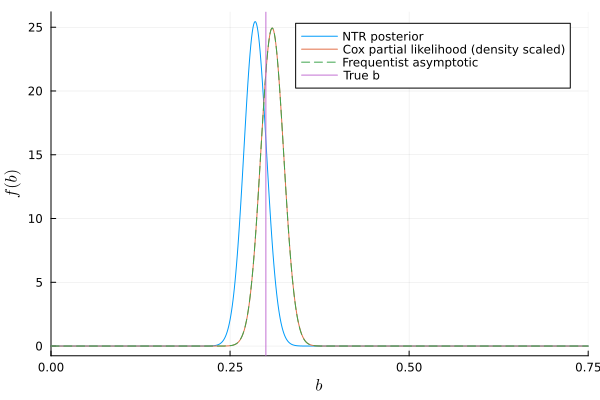

In [13]:
# Cox-NTR model setup and illustration of posterior distribution in regression coefficent
# DataFrame for Survival.jl fit
df = DataFrame(time = T, status = δ, z = [ z[1] for z in Z ])
# Add EvenTime column to DataFrame
df.event = EventTime.( df.time, df.status)
# Fit fequentist Cox model
freq_cox_model = Survival.coxph(@formula(event ~ z), df)
# Frequentist fit of Cox regression coefficient, 
c_freq = coef(freq_cox_model)
# Regression data struct for Cox-NTR modeling
dataregre = RegressionSurvivalData(T,δ,Z)
# Asymptotic vraince components computation
fisherI_obs, V_obs, U_obs  = cox_var_obs(t,c_freq[1],dataregre)
σ_freq_obs = 1 / sqrt( m*fisherI_obs )
# Cox-NTR model variance modualting parameter
α = 5.0
# Compile logLlikelihood evaluation
NTRsurv.loglikelihood([0.3],α,baseline,dataregre) # In this notebbok loglikelihood funcion is also loaded by Survival so it has to be sepcified.
# Illustrative plot of proportional density on b
post_k(v) = exp(NTRsurv.loglikelihood( v, α, baseline, dataregre) - NTRsurv.loglikelihood([b],α,baseline,dataregre))
post_C = hcubature( post_k, [-1.5], [2.0] )[1]
post(z) = post_k(z)/post_C
coxpll_k(v) = exp( cox_partial_loglik(v,dataregre) - cox_partial_loglik(b,dataregre) )
freq_C = hcubature( coxpll_k, [-1.5], [2.0] )[1]
coxpll(z) = coxpll_k(z)/freq_C
# Plot of posterior density on regression coefficient compared with density scaled partial loglikelihood and true coefficient `b=0.3`
plot(collect(-0.5:0.001:0.75), [ post([x])  for x in collect(-0.5:0.001:0.75) ], xlabel="\$b\$", ylabel="\$\\,f\\,(b)\$", label="NTR posterior", xlim=(0.0,0.75) )
plot!(collect(-0.5:0.001:0.75), [ coxpll([x])  for x in collect(-0.5:0.001:0.75) ], label="Cox partial likelihood (density scaled)", xlim=(0.0,0.75) )
plot!(collect(-0.5:0.001:0.75), pdf.(Normal(c_freq[1],σ_freq_obs), collect(-0.5:0.001:0.75)), linestyle=:dash,label="Frequentist asymptotic")
vline!([b],label="True b")

### Posterior mean survival for Cox-NTR models

Let $X^{(\text{new})}$ be a new observation with corresponding covariate vector $\pmb{Z}^{(\text{new})}$. From the posterior characterization of the Cox-NTR model we can obtain a posteror mean estimator for the survival function of $X^{(\text{new})} \,|\,\pmb{Z}^{(\text{new})}$

\begin{align*}
\hat{S}(t; \pmb{Z}^{(\text{new})}) &= \mathbb{E}\left[  \mathbb{P}\left[ X^{(\text{new})} >t \,|\, Y,\, \pmb{c},\, \pmb{Z^{(\text{new})}},\, \pmb{\mathcal{D}}\right] \,|\,\pmb{c},\, \pmb{Z^{(\text{new})}},\, \pmb{\mathcal{D}}\ \right]
= \mathbb{E}\left[e^{-Y^\circ(t) }  \,|\,\pmb{c},\, \pmb{Z^{(\text{new})}},\, \pmb{\mathcal{D}}\  \right] \prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} } \mathbb{E}\left[e^{-W_k} \,|\,\pmb{c},\, \pmb{Z^{(\text{new})}},\, \pmb{\mathcal{D}}\  \right]
\\ &= e^{-\sum_{k=1}^{k_n+1}\left( \psi^{\circ \pmb{Z}^{(\text{new})}}_{t\wedge t_{(k)}}(1) - \psi^{\circ \pmb{Z}^{(\text{new})} }_{t\wedge t_{(k-1)}}(1)  \right) }
\underset{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }{\prod} \frac{ \int_0^\infty e^{- \left( \lambda + \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-\frac{ g\left(\pmb{c},\pmb{Z}_l \right)}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } s } \right) \eta'_{t_{(k)}} \circ m^{-1} (\mathrm{d}s) }{  \int_0^\infty e^{-  \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \prod_{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} } \left( 1 - e^{- \frac{ g_l\left(\pmb{c},\pmb{Z}_l \right) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }s } \right) \eta'_{t_{(k)}}\circ m ^{-1}(\mathrm{d}s)  }
\end{align*}

where $t_{(k_n+1)}=\infty$ and $\psi^{\circ \pmb{Z}^{(\text{new})}}_t(\lambda)= -\log\left( \mathbb{E}\left[ \exp\left( -\lambda Y_{\pmb{c},\pmb{Z}^{(\text{new})}}^\circ(t) \right)\right] \right)$ is the Laplace exponent of $Y_{\pmb{c},\pmb{Z}}^\circ(t)$.

Again, under the case of $\nu$ being homogeneous and such that $\nu(w,(0,t]) = \kappa(t)\rho(w) $ we have the simplification

\begin{align*}
\hat{S}(t) &=  \exp\left( -\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \int_0^\infty e^{ -\frac{ h_k(\pmb{c}) }{  g(\pmb{c},\pmb{Z}^{(\text{new})}) } w}  (1-e^{- w}) \rho\left( \frac{w}{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) \frac{1}{g(\pmb{c},\pmb{Z}^{(\text{new})})}\mathrm{d}w \right)
\\ & \hphantom{==}\times
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }
\frac{ \int_0^\infty e^{- \left( 1 + \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)w } \underset{  \{ l \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\prod} \left( 1 - e^{-\frac{ g\left(\pmb{c},\pmb{Z}_l \right)}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w } \right) \rho\left( \frac{w}{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) \frac{1}{g(\pmb{c},\pmb{Z}^{(\text{new})})}\mathrm{d}w }{  \int_0^\infty e^{-  \frac{ h_k^\star(\pmb{c}) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }w } \prod_{ \{ l  \,:\, t_l= t_{(k)},\,  \delta_l = 1 \} } \left( 1 - e^{- \frac{ g_l\left(\pmb{c},\pmb{Z}_l \right) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) }w } \right) \rho\left( \frac{w}{g(\pmb{c},\pmb{Z}^{(\text{new})})} \right) \frac{1}{g(\pmb{c},\pmb{Z}^{(\text{new})})}\mathrm{d}w }
\end{align*}

and for the Gamma process case in particular we obtain, denoting again  $l_k^\star = \underset{\{ l\,:\, t_l=t_{(k)},\,  \delta_l = 1  \}}{\arg\min}  g\left( \pmb{b},\pmb{Z}_l \right)$, doing a product expasion and using the corresponding Laplace exponent formula,

\begin{align*}
\hat{S}(t) & =  \exp\left( -\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \beta \log\left(1 + \frac{ g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)}{ \alpha + h_k(\pmb{c}) } \right)  \right)
\\ & \hphantom{==}\times
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }
\frac{ \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)} \int_0^\infty e^{- \left( 1 + \frac{ \alpha + h_k^\star(\pmb{c}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \left( 1 - \exp\left( -\frac{ g(\pmb{c},\pmb{Z}_{ l_k^{\star} } )}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w \right) \right) w^{-1} \mathrm{d}w }{  \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)} \int_0^\infty e^{- \left( \frac{ \alpha + h_k^\star(\pmb{c}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \left( 1 - \exp\left( -\frac{ g(\pmb{c},\pmb{Z}_{ l_k^{\star } } )}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w \right) \right) w^{-1} \mathrm{d}w }
\\ & =  \exp\left( -\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \beta \log\left(1 + \frac{ g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)}{ \alpha + h_k(\pmb{c}) } \right)  \right)
\\ & \hphantom{==}\times
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }
\frac{ \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)}  
\log\left( 1 + \frac{ g\left(\pmb{c},\pmb{Z}_{ l_k^{\star} }\right) }{ \alpha + h_k^\star(\pmb{c}) + g(\pmb{c},\pmb{Z}^{(\text{new})}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l)  } \right)
}{  \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)}  
\log\left( 1 + \frac{ g\left(\pmb{c},\pmb{Z}_{ l_k^{\star} }\right) }{ \alpha + h_k^\star(\pmb{c}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l)  } \right)}
\end{align*}

when there are no repetition we get the simplification

\begin{align*}
\hat{S}(t) & =  \exp\left( -\sum_{k=1}^{k_n+1}\left( \kappa( t\wedge t_{(k)} ) - \kappa( t\wedge t_{(k-1)} )  \right) \beta \log\left(1 + \frac{ g\left( \pmb{c},\pmb{Z}^{(\text{new})} \right)}{ \alpha + h_k(\pmb{c}) } \right)  \right)
\\ & \hphantom{==}\times
\prod_{ \{ k \,:\, d_k \geq 1,\, t_{(k)} \leq t \} }
\frac{ \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)} \int_0^\infty e^{- \left( 1 + \frac{ \alpha + h_k^\star(\pmb{c}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \left( 1 - \exp\left( -\frac{ g(\pmb{c},\pmb{Z}_{ l_k^{\star} } )}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w \right) \right) w^{-1} \mathrm{d}w }{  \underset{ S\subset \{ l \neq l_k^\star \,:\, t_l= t_{(k)},\,  \delta_l = 1 \}  }{\sum} (-1)^{\#(S)} \int_0^\infty e^{- \left( \frac{ \alpha + h_k^\star(\pmb{c}) + \underset{ l\in S}{\sum}g(\pmb{c},\pmb{Z}_l) }{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } \right)s } \left( 1 - \exp\left( -\frac{ g(\pmb{c},\pmb{Z}_{ l_k^{\star } } )}{ g(\pmb{c},\pmb{Z}^{(\text{new})}) } w \right) \right) w^{-1} \mathrm{d}w }
\end{align*}

We use Metropolis-Hastings, with Robbins-Monro stochastic approximation algorithm for tuning of proposal variance, for marginal simulation of the regression coefficient $\pmb{c}$. We can evaluate the posterior mean estimator above using a point estimate for $\pmb{c}$. In this example we use the posterior mean obtained from the Markov chain.

Progress: 100%[==================================================] Time: 0:00:12


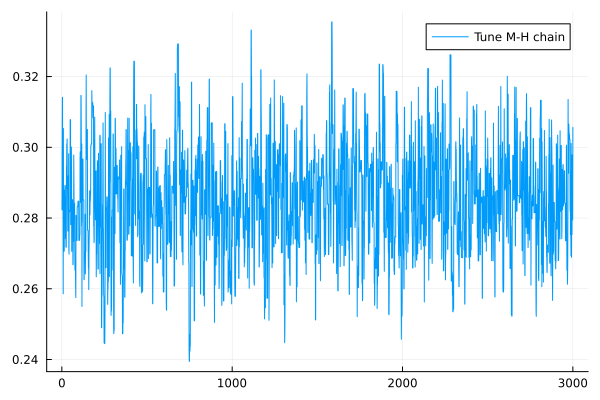

In [14]:
# MCMC run
# Compilation run
robbins_monro_mh_tune(3,3,x->NTRsurv.loglikelihood([x],α,baseline,dataregre),1.0,1.0,0.4,0.7)
#  Robbins-Monro algorithm for variance of proposal distribution tuning
sd_prop_tuned, s₀_tune, lliks₀_tune = robbins_monro_mh_tune(500,250,x->NTRsurv.loglikelihood([x],α,baseline,dataregre),1.0,1.0,0.6,0.7)
# Metropolis-Hastings chain run
chain_s, _ =  random_walk_mh( 3000, x->NTRsurv.loglikelihood([x],α,baseline,dataregre), s₀_tune, lliks₀_tune, sd_prop_tuned[end])
# Acceptance rate in the MH chain, target value was 0.6
acceptance_rate(chain_s)
# Plot MH chain
plot(chain_s,label="Tune M-H chain")

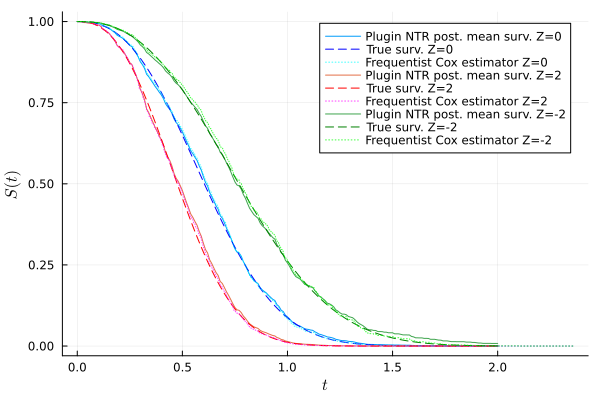

In [15]:
# Illustration of posterior mean comparisson with frequentist Breslow estimator survival curves
# Cox-NTR model setup with MCMC posterior mean regression coefficient and illustration of posterior mean survival
# Posterior mean estimate of regression coefficient
c_post = mean(chain_s)
# NTR model for Cox regression
plugin_cox_model = PluginCoxNeutralToTheRightModel( [c_post], α, baseline, dataregre)
# Breslow estimator for cumulative hazard
Hfreq = BreslowEstimCoxModel(freq_cox_model)
# Frequentists fits of survival curves
zv = [ 0.0, 2.0, -2.0 ]
gv =  exp.( c_freq[1].*zv )
Sfreq0 = [1.0; exp.( - gv[1]*Hfreq )]
Sfreq1 = [1.0; exp.( - gv[2]*Hfreq  )]
Sfreq2 = [1.0; exp.( - gv[3]*Hfreq )]
# Plot posterior mean survival curves in Cox-NTR model
Sm0  = mean_posterior_survival(t, [0.0], plugin_cox_model);
post_mean_regre_plot = plot(t,Sm0,c=1,xlabel="\$t\$", ylabel="\$S(t)\$",label="Plugin NTR post. mean surv. Z=0")
plot!(post_mean_regre_plot, t, ccdf.( Weibull( k, λ), t), c=:blue, linestyle=:dash, label="True surv. Z=0" ) 
plot!( post_mean_regre_plot,[0.0;dataregre.T], Sfreq0, seriestype = :steppost, c=:cyan, linestyle=:dot,alpha=0.75,label="Frequentist Cox estimator Z=0")
Sm1 = mean_posterior_survival(t,[2.0],plugin_cox_model)
plot!(post_mean_regre_plot ,t, Sm1,c=2,label="Plugin NTR post. mean surv. Z=2")
plot!(post_mean_regre_plot, t, ccdf.( Weibull( k, λ/exp(b*2.0/k)), t), c=:red, linestyle=:dash, label="True surv. Z=2" ) 
plot!( post_mean_regre_plot,[0.0;dataregre.T], Sfreq1, seriestype = :steppost, c=:magenta, linestyle=:dot, alpha=0.75,label="Frequentist Cox estimator Z=2")
Sm2 = mean_posterior_survival(t,[-2.0],plugin_cox_model)
plot!( post_mean_regre_plot,t,Sm2,c=3,label="Plugin NTR post. mean surv. Z=-2")
plot!( post_mean_regre_plot, t, ccdf.( Weibull( k, λ/exp(-b*2.0/k)), t), c=:green, linestyle=:dash, label="True surv. Z=-2" ) 
plot!( post_mean_regre_plot, [0.0;dataregre.T], Sfreq2, seriestype = :steppost, c=:lime, linestyle=:dot, alpha=0.75,label="Frequentist Cox estimator Z=-2")

For comparisson we fitted the frequentist Cox model using Survival.jl and plotted the survival curves based on the Breslow estimator for the baseline cumulative hazard function of the frequentist Cox model.

### Posterior simulation of NTR survival functions

From the posterior characterization of the NTR model, we have that simulation of posterior survival draws is feasible by drawing

$$
\pmb{c} | \mathcal{D},\quad \tilde{S}_{\pmb{c},\pmb{Z}^{(\text{new})},\pmb{\mathcal{D} }}(t) = \exp\left( - \tilde{Y}_{\pmb{c},\pmb{Z}^{(\text{new})},\pmb{\mathcal{D}}}(t)  \right) 
$$

It is seen from the posterior characterization that in order to draw simulations of $\tilde{Y}_{\pmb{c},\pmb{Z}^{(\text{new})},\pmb{\mathcal{D}}}$ in $[0,t_f]$ we only need to:

1) Draw Gamma processes in $(t_{(k-1)},t_{(k)}]$ with parameters $\kappa$, $\beta_\alpha$ and $\alpha^\circ= (\alpha+h_k)/g\left(\pmb{c},\pmb{Z}^{(\text{new})} \right)$.

2) Draw random weights, corresponding to fixed jump location $t_{(k)}$,  $W_k\sim\mathcal{L}(f_{k,\pmb{Z}^{(new)}})$.

For the sampling the random weights in the posterior characterization we use an efficient acceptance-rejection sampler in the sense that the probability of acceptance goes to one as $h_k^\star(\pmb{c})$ goes to infinity, provided that $\frac{1}{n}\sum_{i=1}^n \delta_i$ converges to a strictly positive limit. Complexity of the draw for random weights depends on the associated jump location $t_{(k)}$ corresponds to repeated exact observations on the survival data or not. Details on the acceptance-rejection scheme follow next.

##### No repetitions case
Let the kernel of $f_{k,\pmb{Z}^{(\text{new})}}$ be denoted by
$$
f_{k,\pmb{Z}^{(\text{new})}}^{\text{ker}}= e^{-\left( \alpha + r^\star_k \right)s}\left( 1-e^{-s} \right)^{d_k}s^{-1}  
$$
Use proposal distribution $\text{Exp}(\alpha+r_k^\star)$ and accept a draw $V$ from it if for an independent $U\sim\text{Uniform}(0,1)$
$$
\frac{1-e^{-V}}{V}\leq U.
$$ 

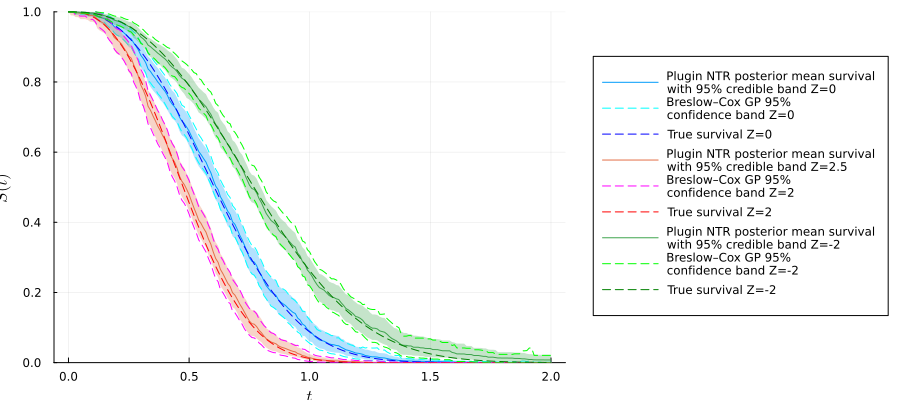

In [16]:
# Computation and illustration of posterior credible bands
Hv = step_eval(dataregre.T,Hfreq,t;left=0.0)
Un_obs(v) = step_eval(t,U_obs,v;left=0.0)
zv = [ 0.0, 2.0, -2.0 ]
Sfreqdraws = Sfreq_mat(3000,m,t,Hv,gv,zv,Un_obs,V_obs,fisherI_obs)
freq_band_0 = credible_band(t,0.05,Sfreqdraws[1])
freq_band_1 = credible_band(t,0.05,Sfreqdraws[2])
freq_band_2 = credible_band(t,0.05,Sfreqdraws[3])
plugin_cred0 = posterior_credible_band(0.05,3000,t, [0.0], plugin_cox_model)
plugin_cred1 = posterior_credible_band(0.05,3000,t, [2.0], plugin_cox_model)
plugin_cred2 = posterior_credible_band(0.05,3000,t, [-2.0], plugin_cox_model)
post_regre_draws_plot = plot( plugin_cred0, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Plugin NTR posterior mean survival \nwith 95% credible band Z=0", legend=:outerright)
plot!( post_regre_draws_plot, t, freq_band_0.u, color=:cyan, linestyle=:dash, label="Breslow–Cox GP 95% \nconfidence band Z=0")
plot!( post_regre_draws_plot, t, freq_band_0.d, color=:cyan, linestyle=:dash, label="")
plot!(post_regre_draws_plot, t, ccdf.( Weibull( k, λ), t), c=:blue, linestyle=:dash, label="True survival Z=0" ) 
plot!(post_regre_draws_plot, plugin_cred1, c=2,label="Plugin NTR posterior mean survival \nwith 95% credible band Z=2.5")
plot!( post_regre_draws_plot, t, freq_band_1.u, color=:magenta, linestyle=:dash, label="Breslow–Cox GP 95% \nconfidence band Z=2")
plot!( post_regre_draws_plot, t, freq_band_1.d, color=:magenta, linestyle=:dash,label="")
plot!(post_regre_draws_plot, t, ccdf.( Weibull( k, λ/exp(b*2.0/k)), t), c=:red, linestyle=:dash, label="True survival Z=2" ) 
plot!(post_regre_draws_plot, plugin_cred2, c=3,label="Plugin NTR posterior mean survival \nwith 95% credible band Z=-2")
plot!( post_regre_draws_plot, t, freq_band_2.u, color=:lime, linestyle=:dash, label="Breslow–Cox GP 95% \nconfidence band Z=-2")
plot!( post_regre_draws_plot, t, freq_band_2.d, color=:lime, linestyle=:dash,label="")
plot!(post_regre_draws_plot, t, ccdf.( Weibull( k, λ/exp(-b*2.0/k)), t), c=:green, linestyle=:dash, label="True survival Z=-2" , title="", size=(900,400),)

Alternatively, a fully Bayesian model can be considered where instead of plugging an estimator of the regression coefficient, we treat it as random with samples coming from the Markov chain that was computed above. We ccompare the posterior mean survivals and credible bands between the non-fully and fully Bayesian models to see that there is not much difference.

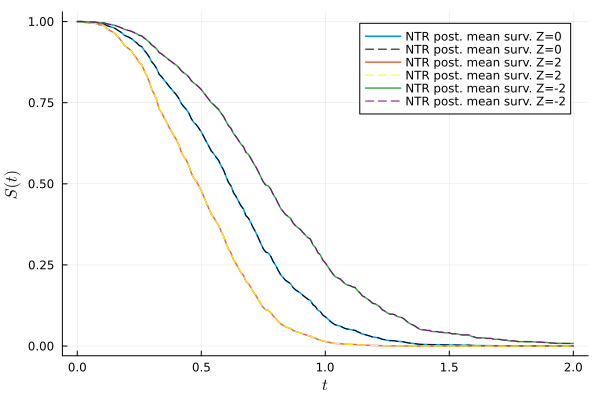

In [17]:
# Computation and posterior mean illustration of fully Bayesian Cox-NTR model
cox_model = CoxNeutralToTheRightModel([ [v] for v in chain_s], α, baseline, dataregre)
Sfbm0  = mean_posterior_survival(t, [0.0], cox_model)
Sfbm1 = mean_posterior_survival(t,[2.0], cox_model)
Sfbm2 = mean_posterior_survival(t,[-2.0], cox_model)
compare_post_regre_plot = plot(t,Sm0,c=1, linewidth=1.5, xlabel="\$t\$", ylabel="\$S(t)\$",label="NTR post. mean surv. Z=0")
plot!( compare_post_regre_plot, t , Sfbm0, c=:black, linestyle=:dash, label="NTR post. mean surv. Z=0")
plot!( compare_post_regre_plot, t, Sm1, c=2, linewidth=1.5, label="NTR post. mean surv. Z=2")
plot!( compare_post_regre_plot, t , Sfbm1, c=:yellow, linestyle=:dash, label="NTR post. mean surv. Z=2")
plot!( compare_post_regre_plot, t,Sm2,c=3,linewidth=1.5, label="NTR post. mean surv. Z=-2")
plot!( compare_post_regre_plot, t, Sfbm2, c=:purple, linestyle=:dash, label="NTR post. mean surv. Z=-2")

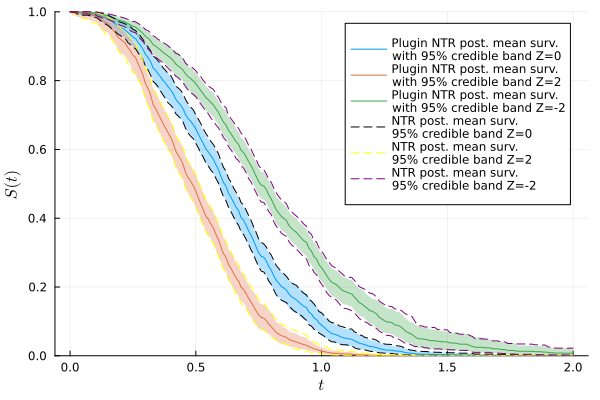

In [18]:
# Computation and illustration of fully Bayesian Cox-NTR model credible bands
cred0 = posterior_credible_band(0.05, t, [0.0], cox_model)
cred1 = posterior_credible_band(0.05, t, [2.0], cox_model)
cred2 = posterior_credible_band(0.05, t, [-2.0], cox_model)
post_fully_bayes_regre_draws_plot = plot( plugin_cred0, xlabel="\$t\$", ylabel="\$S(t)\$", fillalpha=0.3, label="Plugin NTR post. mean surv. \nwith 95% credible band Z=0",size=(600,400))
plot!(post_fully_bayes_regre_draws_plot, plugin_cred1, c=2,label="Plugin NTR post. mean surv. \nwith 95% credible band Z=2")
plot!(post_fully_bayes_regre_draws_plot, plugin_cred2, c=3,label="Plugin NTR post. mean surv. \nwith 95% credible band Z=-2")
plot!(post_fully_bayes_regre_draws_plot, t, cred0.d,  c=:black, linestyle=:dash, label="NTR post. mean surv. \n95% credible band Z=0")
plot!(post_fully_bayes_regre_draws_plot, t, cred0.u,  c=:black, linestyle=:dash, label="")
plot!(post_fully_bayes_regre_draws_plot, t, cred1.d,  c=:yellow, linestyle=:dash, label="NTR post. mean surv. \n95% credible band Z=2")
plot!(post_fully_bayes_regre_draws_plot, t, cred1.u,  c=:yellow, linestyle=:dash, label="")
plot!(post_fully_bayes_regre_draws_plot, t, cred2.d,  c=:purple, linestyle=:dash, label="NTR post. mean surv. \n95% credible band Z=-2")
plot!(post_fully_bayes_regre_draws_plot, t, cred2.u,  c=:purple, linestyle=:dash, label="",title="",size=(600,400))

The similarity between the fully Bayesian Cox-NTR survival estimates and the plug-in Cox-NTR approach should not be surprising as the Bernstein-von Mises theorem implies that for relatively big sample the posterior density of the regression coefficients accumulates near the truth. However also in small sampe size regimes, since computational complexity of the fully Bayes approach requires computing Cox risk-set sufficient statistics across posterior draws of the regression coefficient, the plug-in approach is to be preferred as it provides a substantially cheaper default workflow. We therefore recommend the plug-in Cox-NTR analysis for routine use, while retaining the fully Bayesian version as an optional sensitivity analysis for small samples, weakly identified regression effects, or predictions at extreme covariate values.

## References

- Doksum, K. (1974). [Tailfree and neutral random probabilities and their posterior distributions](https://doi.org/10.1214/aop/1176996703). *The Annals of Probability*, 2(2), 183–201.
- Ghosal, S., & van der Vaart, A. W. (2017). [*Fundamentals of Nonparametric Bayesian Inference*](https://www.cambridge.org/core/books/fundamentals-of-nonparametric-bayesian-inference/C96325101025D308C9F31F4470DEA2E8). Cambridge University Press.
- Kim, Y. (2006). [The Bernstein–von Mises theorem for the proportional hazard model](https://projecteuclid.org/journals/annals-of-statistics/volume-34/issue-4/The-Bernsteinvon-Mises-theorem-for-the-proportional-hazard-model/10.1214/009053606000000533.full). *The Annals of Statistics*, 34(4), 1978–2000.
- Riva-Palacio, A. (2019). [*Bayesian Nonparametric Methods for Heterogeneous Data*](https://kar.kent.ac.uk/74521/) [Doctoral dissertation] Kent Academic Repository.
- Riva-Palacio, A., Leisen, F., & Griffin, J. (2022). [Survival regression models with dependent Bayesian nonparametric priors](https://doi.org/10.1080/01621459.2020.1864381). *Journal of the American Statistical Association*, 117(539), 1530–1539.